# Import libraries

In [1]:
import pandas as pd
import numpy as np
from copy import deepcopy
from IPython.core.display import HTML
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from feature_engine.imputation import AddMissingIndicator, ArbitraryNumberImputer, MeanMedianImputer
from kvbiii_ml.data_processing.data_imputation.statistical_association_imputation import StatisticalAssociationImputer

from kvbiii_plots.eda.categorical_plots import CategoricalPlots
categorical_plots = CategoricalPlots()
from kvbiii_plots.eda.continuous_plots import ContinuousPlots
continuous_plots = ContinuousPlots()
from kvbiii_plots.ml.optuna_plots import OptunaPlots
optuna_plots = OptunaPlots()
from kvbiii_plots.evaluation.classification_plots import ClassificationPlots
classification_plots = ClassificationPlots()
from kvbiii_plots.ml.other_plots import OtherPlots
other_plots = OtherPlots()

from kvbiii_ml.data_processing.eda.data_analysis import DataAnalyzer
data_analyzer = DataAnalyzer()
from kvbiii_ml.data_processing.eda.data_cleaning import DataCleaner
data_cleaner = DataCleaner()
from kvbiii_ml.data_processing.eda.data_transformation import DataTransformer
data_transformer = DataTransformer()
from kvbiii_ml.data_processing.data_imputation.joint_distribution_imputation import impute_missing_values
from kvbiii_ml.data_processing.feature_engineering.cross_encoding import CrossFeatureGenerator
from kvbiii_ml.data_processing.feature_engineering.count_encoding import CountEncodingFeatureGenerator
from kvbiii_ml.data_processing.feature_engineering.target_encoding import TargetEncodingFeatureGenerator
from kvbiii_ml.data_processing.feature_engineering.feature_generation_pipeline import FeatureGenerationPipeline
from kvbiii_ml.modeling.training.cross_validation import CrossValidationTrainer
from kvbiii_ml.modeling.training.ensemble_model import EnsembleModel
from kvbiii_ml.data_processing.feature_selection.shap_rfe import ShapRecursiveFeatureElimination
from kvbiii_ml.modeling.optimization.hyperparameter_tuning import RandomSearchCV
from kvbiii_ml.modeling.optimization.ensemble_weights_tuner import EnsembleWeightTunerCV
from kvbiii_ml.modeling.optimization.cutoff_tuning import CutoffTunerCV
from kvbiii_ml.evaluation.metrics import METRICS
from kvbiii_ml.evaluation.generate_reports import classification_results

SEED = 17
PROBLEM_TYPE = "classification"
METRIC_NAME = "Accuracy"
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
N_TRIALS = 100

cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, verbose=False)

# Load dataset

In [2]:
train_data = pd.read_csv('input/train.csv', index_col='id')
test_data = pd.read_csv('input/test.csv', index_col='id')
target_feature = "Personality"
# train_data, test_data = train_test_split(train_data[:250], test_size=0.2, random_state=SEED, stratify=train_data[target_feature][:250])
train_data

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert
...,...,...,...,...,...,...,...,...
18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,1.0,NaN,6.0,7.0,No,6.0,5.0,Extrovert
18521,7.0,Yes,1.0,1.0,Yes,1.0,NaN,Introvert


In [3]:
data_analyzer.base_information(train_data)

,Feature,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,Time_spent_Alone,float64,"1,190",6.42%,12,"17,334"
1,Stage_fear,object,"1,893",10.22%,2,"16,631"
2,Social_event_attendance,float64,"1,180",6.37%,11,"17,344"
3,Going_outside,float64,"1,466",7.91%,8,"17,058"
4,Drained_after_socializing,object,"1,149",6.20%,2,"17,375"
5,Friends_circle_size,float64,"1,054",5.69%,16,"17,470"
6,Post_frequency,float64,"1,264",6.82%,11,"17,260"
7,Personality,object,0,0.00%,2,"18,524"


In [4]:
data_analyzer.base_information(test_data)

,Feature,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,Time_spent_Alone,float64,425,6.88%,12,"5,750"
1,Stage_fear,object,598,9.68%,2,"5,577"
2,Social_event_attendance,float64,397,6.43%,11,"5,778"
3,Going_outside,float64,466,7.55%,8,"5,709"
4,Drained_after_socializing,object,432,7.00%,2,"5,743"
5,Friends_circle_size,float64,350,5.67%,16,"5,825"
6,Post_frequency,float64,408,6.61%,11,"5,767"


# Initial features cleaning

In [5]:
train_data = data_cleaner.initial_features_removal(train_data)


Number of features after removal: 8. Removed 0 features.


## ❌ Dropped Features

Remove those features that have at least threshold (default 0.99) of values in one category (are extremely unbalanced)

In [6]:
categorical_features = data_analyzer.get_categorical_features(train_data, unique_threshold=100)
train_data = data_cleaner.drop_highly_skewed_categorical_features(train_data, features_to_investigate=train_data.drop(columns=[target_feature]).columns.tolist(), threshold=0.99)
categorical_features = data_analyzer.get_categorical_features(train_data, unique_threshold=100)

## Duplicates

In [7]:
print(f"Number of duplicated rows: {train_data.duplicated().sum()}")
train_data = train_data.drop_duplicates(keep='last').reset_index(drop=True)
print(f"Number of duplicated rows after removal: {train_data.duplicated().sum()}")

Number of duplicated rows: 0
Number of duplicated rows after removal: 0


# Missing values

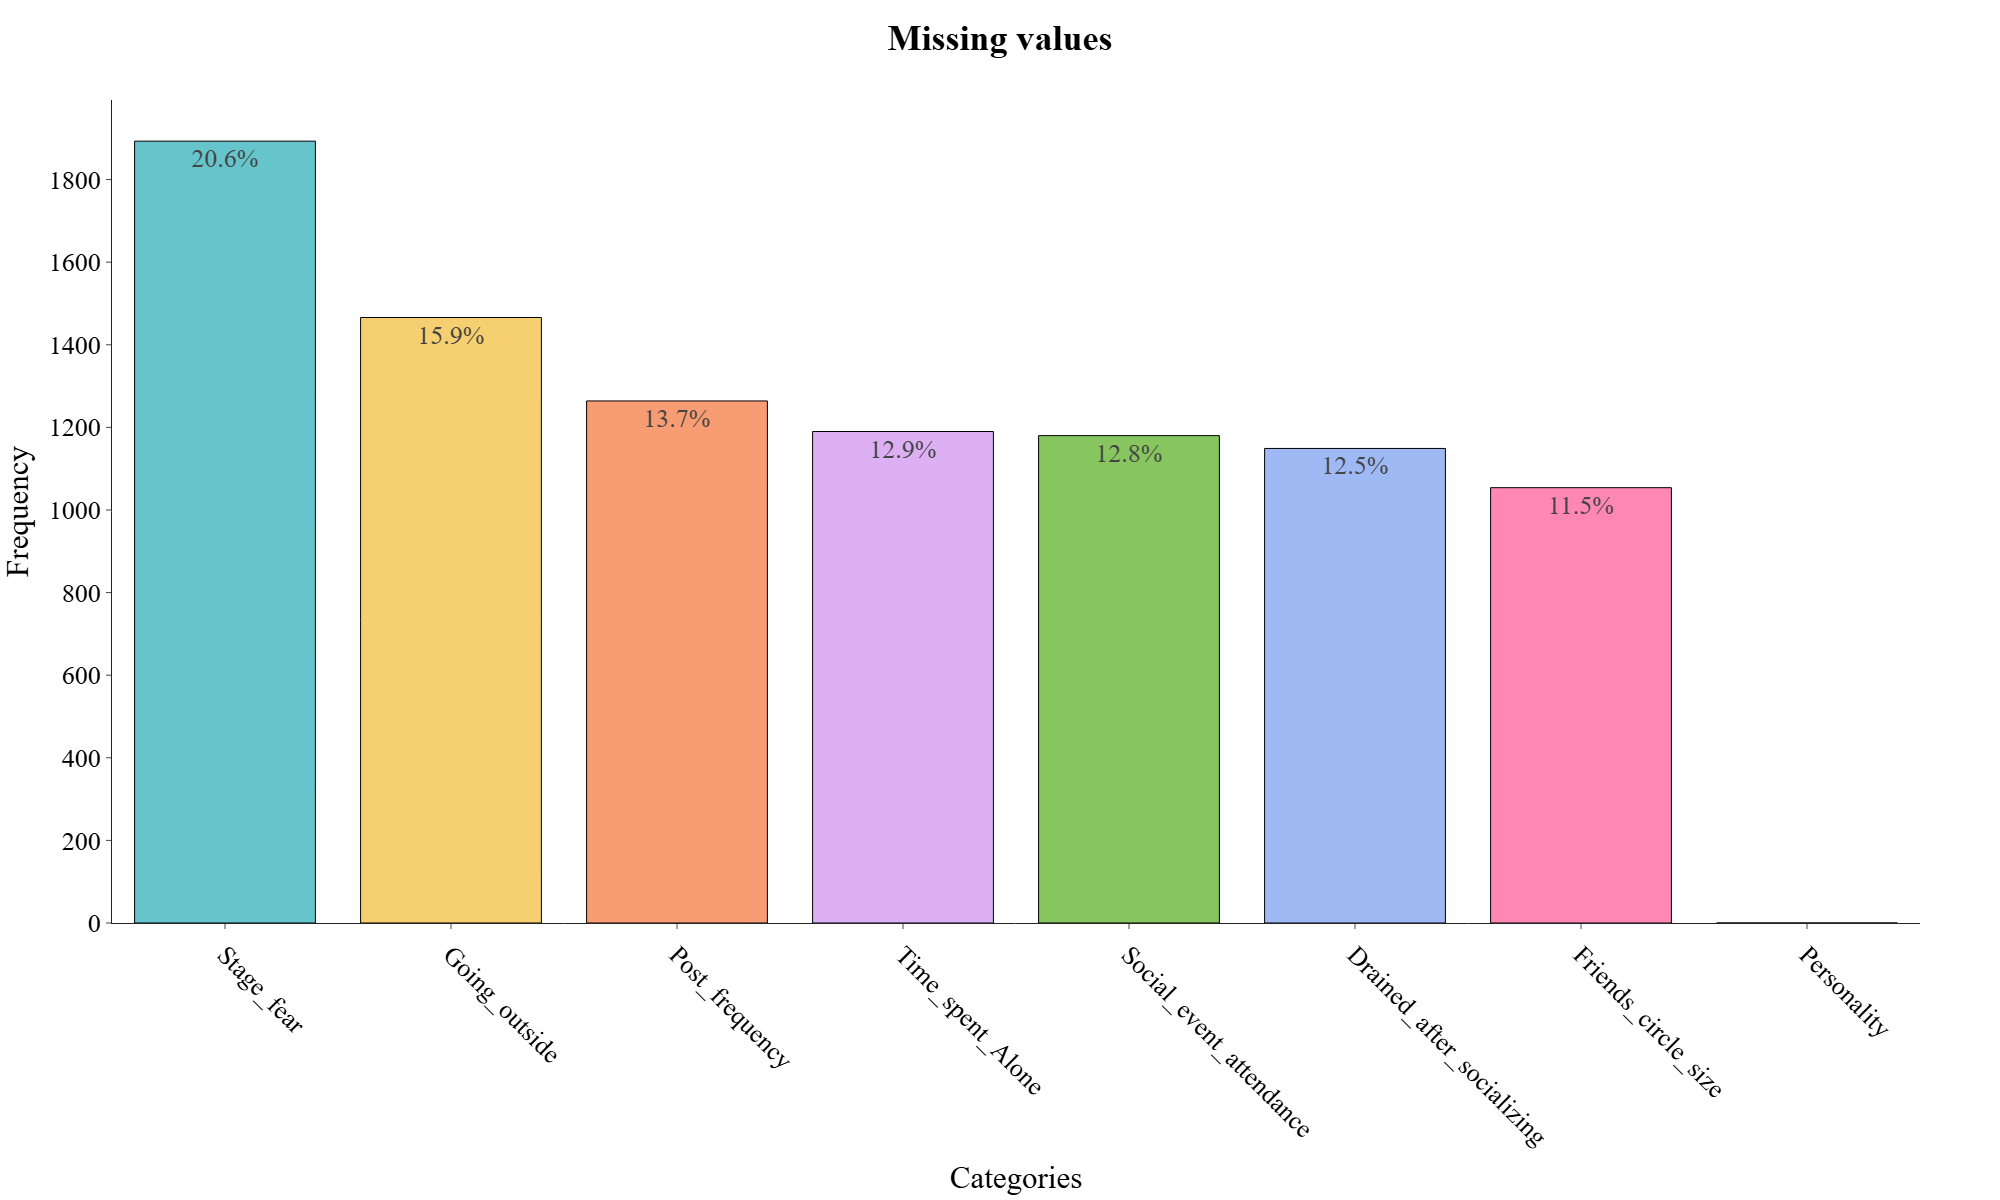

In [8]:
categorical_plots.barplot(train_data.isna().sum(), plot_title=f"Missing values", top_n=20, show_other=False, tickangle=45, width=2000, height=1200)

## Categorical Features

In [9]:
categorical_features_by_missing = data_cleaner.categorize_categorical_features_by_missing(train_data, categorical_features)

### Initial imputation based on some insights from data analysis

In [10]:
train_data = impute_missing_values(train_data, categorical_features_by_missing["categorical_missing_features"], categorical_features_by_missing["non_missing_categorical_features"], threshold_num_observation=1)

### Further categorical features imputation

In [11]:
output = []
for col in categorical_features_by_missing["categorical_missing_features"]:
    output.append(data_analyzer.describe_categorical_feature(train_data, col, top_n=15).to_html())
    output.append("\n")
display(HTML("<br>".join(output)))

,Category,Count,Percentage (%)
0,No,"13,313",71.87%
1,Yes,"4,062",21.93%
,Category,Count,Percentage (%)
0,No,"12,609",68.07%
1,Yes,"4,022",21.71%


- Column name: `Drained_after_socializing`
- Chosen strategy: Keep null values as a separate category 'Unknown'
- Justification: The column is binary, and the missing values might represent a specific state (e.g., "not applicable" or "unknown"). Keeping them as a separate category allows the model to learn from this information.

In [12]:
train_data['Drained_after_socializing'] = train_data['Drained_after_socializing'].fillna('Unknown')
train_data['Drained_after_socializing'] = train_data['Drained_after_socializing'].astype('category')
test_data['Drained_after_socializing'] = test_data['Drained_after_socializing'].fillna('Unknown')
test_data['Drained_after_socializing'] = pd.Categorical(
    test_data['Drained_after_socializing'],
    categories=train_data['Drained_after_socializing'].cat.categories
)

- Column name: `Stage_fear`
- Chosen strategy: Keep null values as a separate category 'Unknown'
- Justification: The column is binary, and the missing values might represent a specific state (e.g., "not applicable" or "unknown"). Keeping them as a separate category allows the model to learn from this information.

In [13]:
train_data['Stage_fear'] = train_data['Stage_fear'].fillna('Unknown')
train_data['Stage_fear'] = train_data['Stage_fear'].astype('category')
test_data['Stage_fear'] = test_data['Stage_fear'].fillna('Unknown')
test_data['Stage_fear'] = pd.Categorical(
    test_data['Stage_fear'],
    categories=train_data['Stage_fear'].cat.categories
)

## Object Features

In [14]:
object_features = train_data.select_dtypes(include=['object']).columns
object_missing_features = [col for col in object_features if train_data[col].isnull().mean() > 0.0]
output = []
for col in object_missing_features:
    output.append(data_analyzer.describe_categorical_feature(train_data, col, top_n=5).to_html())
    output.append("\n")
display(HTML("<br>".join(output)))

## Numerical Features

In [15]:
numerical_columns = train_data.select_dtypes(include=['number']).columns
numerical_missing_columns = [col for col in numerical_columns if train_data[col].isnull().mean() > 0.0]
output = []
for col in numerical_missing_columns:
    output.append(data_analyzer.describe_numerical_feature(train_data, col).to_html())
    output.append("\n")
display(HTML("<br>".join(output)))

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Time_spent_Alone,"17,334",3.14,3.00,0.00,0.00,1.00,2.00,4.00,10.00,11.00,9.02,1.13,0.35
,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Social_event_attendance,"17,344",5.27,2.75,0.00,0.00,3.00,5.00,8.00,9.00,10.00,7.58,-0.23,-0.93
,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Going_outside,"17,058",4.04,2.06,0.00,0.00,3.00,4.00,6.00,7.00,7.00,4.25,-0.37,-0.78
,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Friends_circle_size,"17,470",8.00,4.22,0.00,1.00,5.00,8.00,12.00,15.00,15.00,17.84,-0.05,-1.08
,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Post_frequency,"17,260",4.98,2.88,0.00,0.00,3.00,5.00,7.00,9.00,10.00,8.29,-0.06,-1.07


# Imputation Strategies

In [16]:
independent_features = train_data.drop(columns=[target_feature]).columns.tolist()
model = LGBMClassifier(boosting_type='gbdt', random_state=SEED, n_jobs=-1, objective='binary', metric='binary_logloss', verbose=-1, early_stopping=100)
# model = XGBClassifier(booster="gbtree", random_state=SEED, n_jobs=-1, objective='binary:logistic', eval_metric='auc', enable_categorical=True, tree_method='hist', verbosity=0, early_stopping_rounds=100)

In [17]:
imputation_results = []

# 1. No imputation (baseline)
print("🔄 Testing baseline (no imputation)...")
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=None, verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "None (Baseline)",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 2. Missing indicator
print("\n🔄 Testing Missing Indicator...")
missing_indicator = AddMissingIndicator(variables=numerical_missing_columns)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[missing_indicator], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "Missing Indicator",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 3. Arbitrary constant imputation for numerical features
print("\n🔄 Testing Arbitrary constant imputation (numerical features)...")
arbitrary_imputer = ArbitraryNumberImputer(arbitrary_number=-1, variables=numerical_missing_columns)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[arbitrary_imputer], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "Arbitrary Constant Imputation",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 4. Mean imputation for numerical features
print("\n🔄 Testing Mean imputation (numerical features)...")
mean_imputer = MeanMedianImputer(imputation_method='mean', variables=numerical_missing_columns)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[mean_imputer], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "Mean Imputation",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 5. Median imputation for numerical features
print("\n🔄 Testing Median imputation (numerical features)...")
median_imputer = MeanMedianImputer(imputation_method='median', variables=numerical_missing_columns)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[median_imputer], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "Median Imputation",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 6. Statistical Association imputation for numerical features
print("\n🔄 Testing Statistical Association imputation (numerical features)...")
statistical_imputer = StatisticalAssociationImputer(metrics=['cramers_v', 'mutual_info', 'theils_u'], top_n=2, verbose=False)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[statistical_imputer], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "Statistical Association Imputation",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 7. Arbitrary constant imputation for numerical features + Missing Indicator
print("\n🔄 Testing Arbitrary constant imputation with Missing Indicator (numerical features)...")
arbitrary_imputer = ArbitraryNumberImputer(arbitrary_number=-1, variables=numerical_missing_columns)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[missing_indicator, arbitrary_imputer], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "Arbitrary Constant Imputation with Missing Indicator",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 8. Mean imputation for numerical features + Missing Indicator
print("\n🔄 Testing Mean imputation with Missing Indicator (numerical features)...")
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[missing_indicator, mean_imputer], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "Mean Imputation with Missing Indicator",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 9. Median imputation for numerical features + Missing Indicator
print("\n🔄 Testing Median imputation with Missing Indicator (numerical features)...")
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[missing_indicator, median_imputer], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "Median Imputation with Missing Indicator",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 10. Statistical Association imputation for numerical features + Missing Indicator
print("\n🔄 Testing Statistical Association imputation with Missing Indicator (numerical features)...")
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[missing_indicator, statistical_imputer], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
imputation_results.append({
    "Imputation": "Statistical Association Imputation with Missing Indicator",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

imputation_results_df = pd.DataFrame(imputation_results)
imputation_results_df = imputation_results_df[["Imputation", "Train Mean", "Train Std", "Valid Mean", "Valid Std"]]
imputation_results_df.style.set_caption("📝 Imputation Comparison") \
    .format({
        "Train Mean": "{:.4f}",
        "Train Std": "{:.4f}",
        "Valid Mean": "{:.4f}",
        "Valid Std": "{:.4f}"
    }) \
    .bar(subset=["Valid Mean"], color="#4a90e2", vmin=0, vmax=1) \
    .set_properties(**{
        'text-align': 'left',
        'font-family': 'Times New Roman',
        'font-size': '1.25em',
        'background-color': '#f9f9f9',
        'border': '1px solid #ddd',
        'color': '#333'
    }) \
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('border', '1px solid #ddd')]}])

🔄 Testing baseline (no imputation)...
Train Accuracy: 0.9704 +- 0.0006
Validation Accuracy: 0.9690 +- 0.0021

🔄 Testing Missing Indicator...
Train Accuracy: 0.9704 +- 0.0006
Validation Accuracy: 0.9690 +- 0.0021

🔄 Testing Arbitrary constant imputation (numerical features)...
Train Accuracy: 0.9701 +- 0.0005
Validation Accuracy: 0.9690 +- 0.0021

🔄 Testing Mean imputation (numerical features)...
Train Accuracy: 0.9703 +- 0.0006
Validation Accuracy: 0.9686 +- 0.0022

🔄 Testing Median imputation (numerical features)...
Train Accuracy: 0.9702 +- 0.0007
Validation Accuracy: 0.9687 +- 0.0021

🔄 Testing Statistical Association imputation (numerical features)...
Train Accuracy: 0.9704 +- 0.0005
Validation Accuracy: 0.9688 +- 0.0022

🔄 Testing Arbitrary constant imputation with Missing Indicator (numerical features)...
Train Accuracy: 0.9701 +- 0.0005
Validation Accuracy: 0.9690 +- 0.0020

🔄 Testing Mean imputation with Missing Indicator (numerical features)...
Train Accuracy: 0.9704 +- 0.0008

,Imputation,Train Mean,Train Std,Valid Mean,Valid Std
0,None (Baseline),0.9704,0.0006,0.9690,0.0021
1,Missing Indicator,0.9704,0.0006,0.9690,0.0021
2,Arbitrary Constant Imputation,0.9701,0.0005,0.9690,0.0021
3,Mean Imputation,0.9703,0.0006,0.9686,0.0022
4,Median Imputation,0.9702,0.0007,0.9687,0.0021
5,Statistical Association Imputation,0.9704,0.0005,0.9688,0.0022
6,Arbitrary Constant Imputation with Missing Indicator,0.9701,0.0005,0.9690,0.0020
7,Mean Imputation with Missing Indicator,0.9704,0.0008,0.9688,0.0020
8,Median Imputation with Missing Indicator,0.9702,0.0007,0.9689,0.0023
9,Statistical Association Imputation with Missing Indicator,0.9703,0.0005,0.9690,0.0021


In [18]:
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[missing_indicator, mean_imputer], verbose=False)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[], verbose=False)

# Features exploration

In [19]:
features = train_data.columns.tolist()
features = [(feature, train_data[feature].dtype) for feature in features]
for feature, dtype in features:
    print(f"- {feature} ({dtype})", end="\n")

- Time_spent_Alone (float64)
- Stage_fear (category)
- Social_event_attendance (float64)
- Going_outside (float64)
- Drained_after_socializing (category)
- Friends_circle_size (float64)
- Post_frequency (float64)
- Personality (object)


## 📚 Dataset Column Descriptions

- `Personality` (category): The target variable representing personality type classification, distinguishing between introversion and extroversion.
- `Time_spent_Alone` (float64): The amount of time an individual prefers to spend in solitude, measured on a numerical scale representing hours per day or preference level.
- `Stage_fear` (category): Whether the person experiences anxiety or fear when performing or speaking in front of an audience (Yes/No/Unknown).
- `Social_event_attendance` (float64): The frequency or preference level for attending social gatherings, parties, or group events, measured on a numerical scale.
- `Going_outside` (float64): The frequency or preference for outdoor activities and leaving one's home environment, measured on a numerical scale.
- `Drained_after_socializing` (category): Whether the person feels emotionally or physically drained after social interactions (Yes/No/Unknown).
- `Friends_circle_size` (float64): The number of close friends or the size of one's social network, measured numerically.
- `Post_frequency` (float64): How often the person posts content on social media platforms, measured on a frequency scale.

# Feature Analysis

## `Personality`

`Personality` (category) - The target variable representing personality type classification, distinguishing between introversion and extroversion.

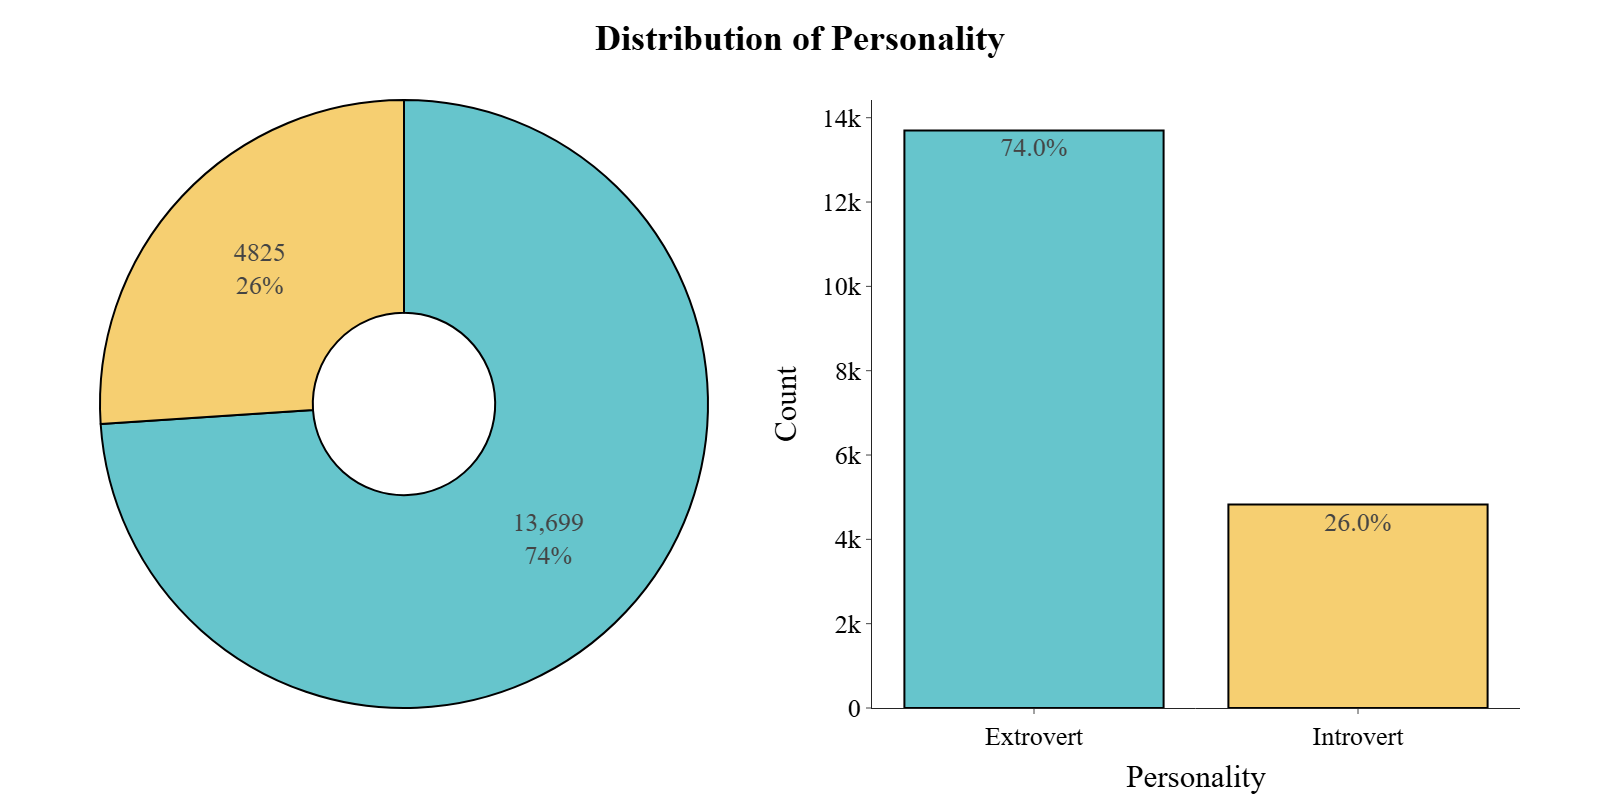

,Category,Count,Percentage (%)
0,Extrovert,"13,699",73.95%
1,Introvert,"4,825",26.05%


In [20]:
categorical_plots.pie_barplot(train_data, target_feature, plot_title=f"Distribution of {target_feature}")
data_analyzer.describe_categorical_feature(train_data, target_feature)

**Notes:**

**Conclusion:**

## `Time_spent_Alone`

`Time_spent_Alone` (float64) - The amount of time an individual prefers to spend in solitude, measured on a numerical scale representing hours per day or preference level.

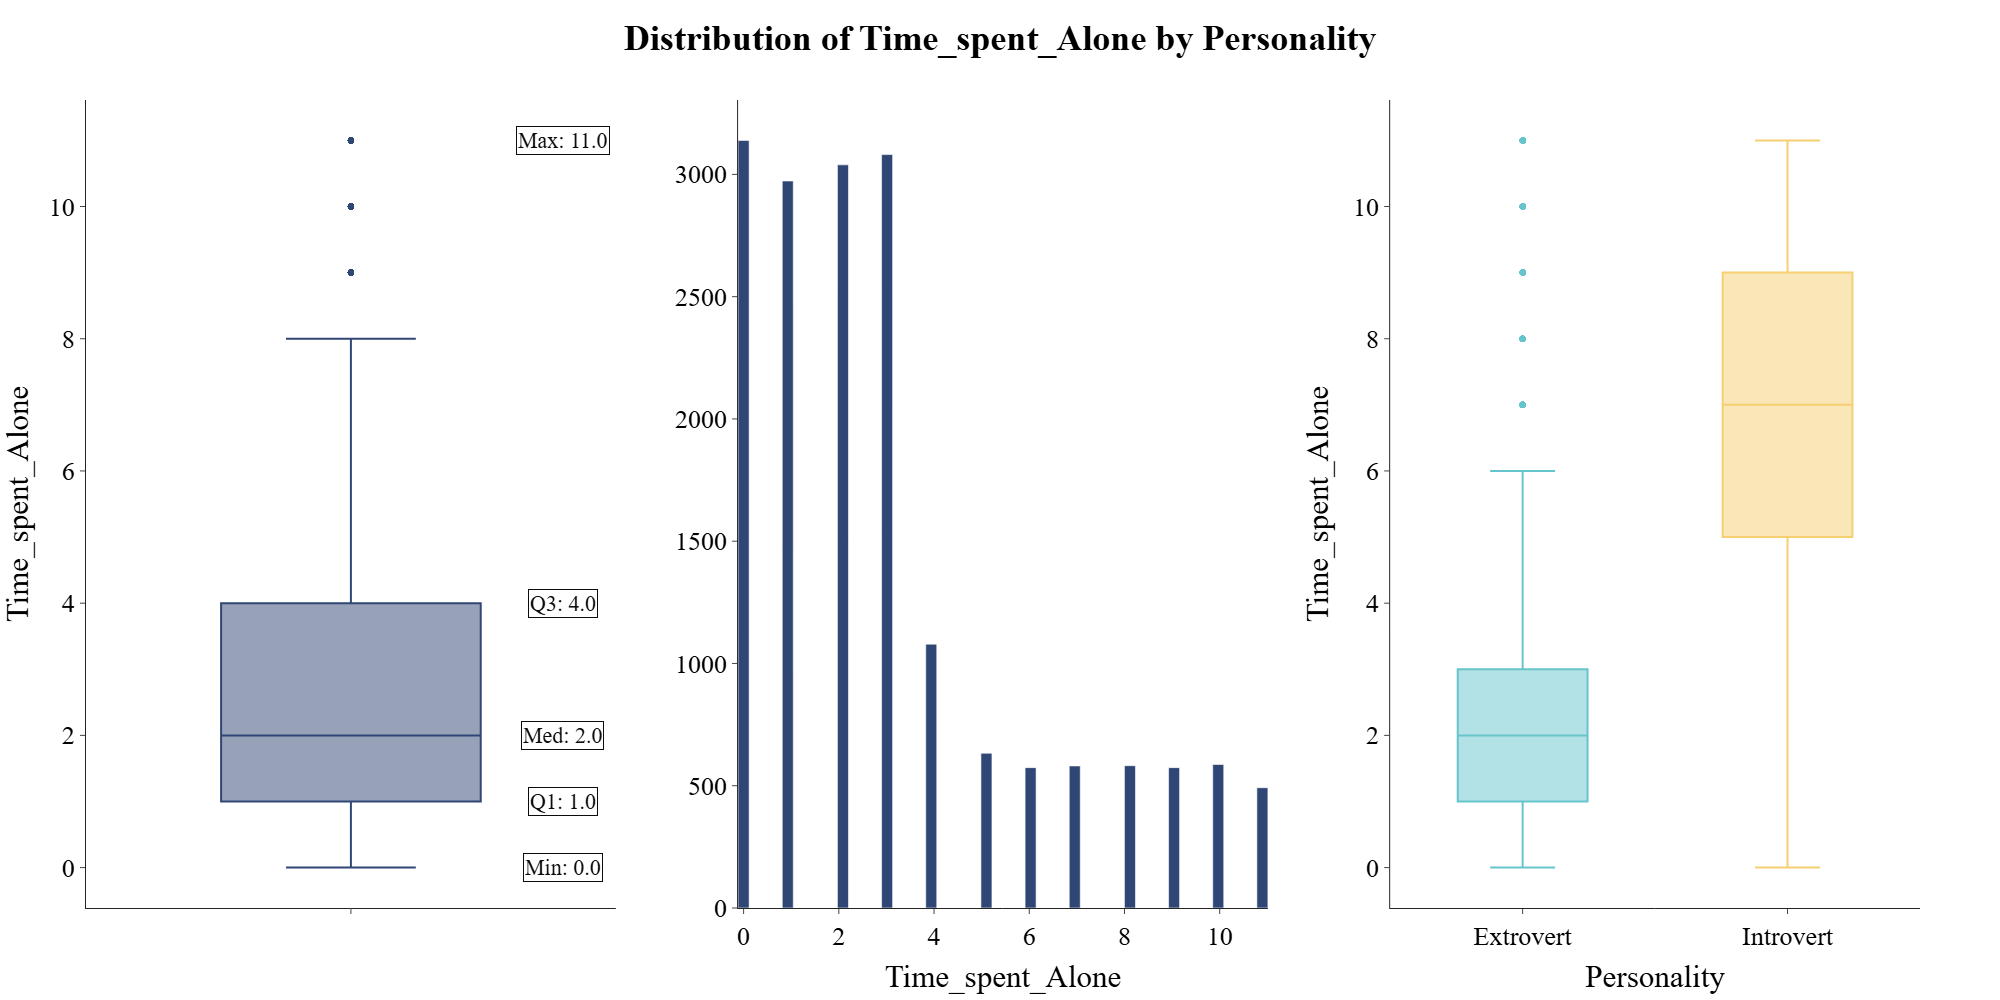

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Time_spent_Alone,"17,334",3.14,3.00,0.00,0.00,1.00,2.00,4.00,10.00,11.00,9.02,1.13,0.35


In [21]:
continuous_plots.boxplot_histogram_boxplot_by_hue(train_data, 'Time_spent_Alone', target_feature, plot_title=f"Distribution of Time_spent_Alone by {target_feature}")
data_analyzer.describe_numerical_feature(train_data, 'Time_spent_Alone')

**Notes:**

**Conclusion:**

## `Stage_fear`

`Stage_fear` (category) - Whether the person experiences anxiety or fear when performing or speaking in front of an audience (Yes/No/Unknown).

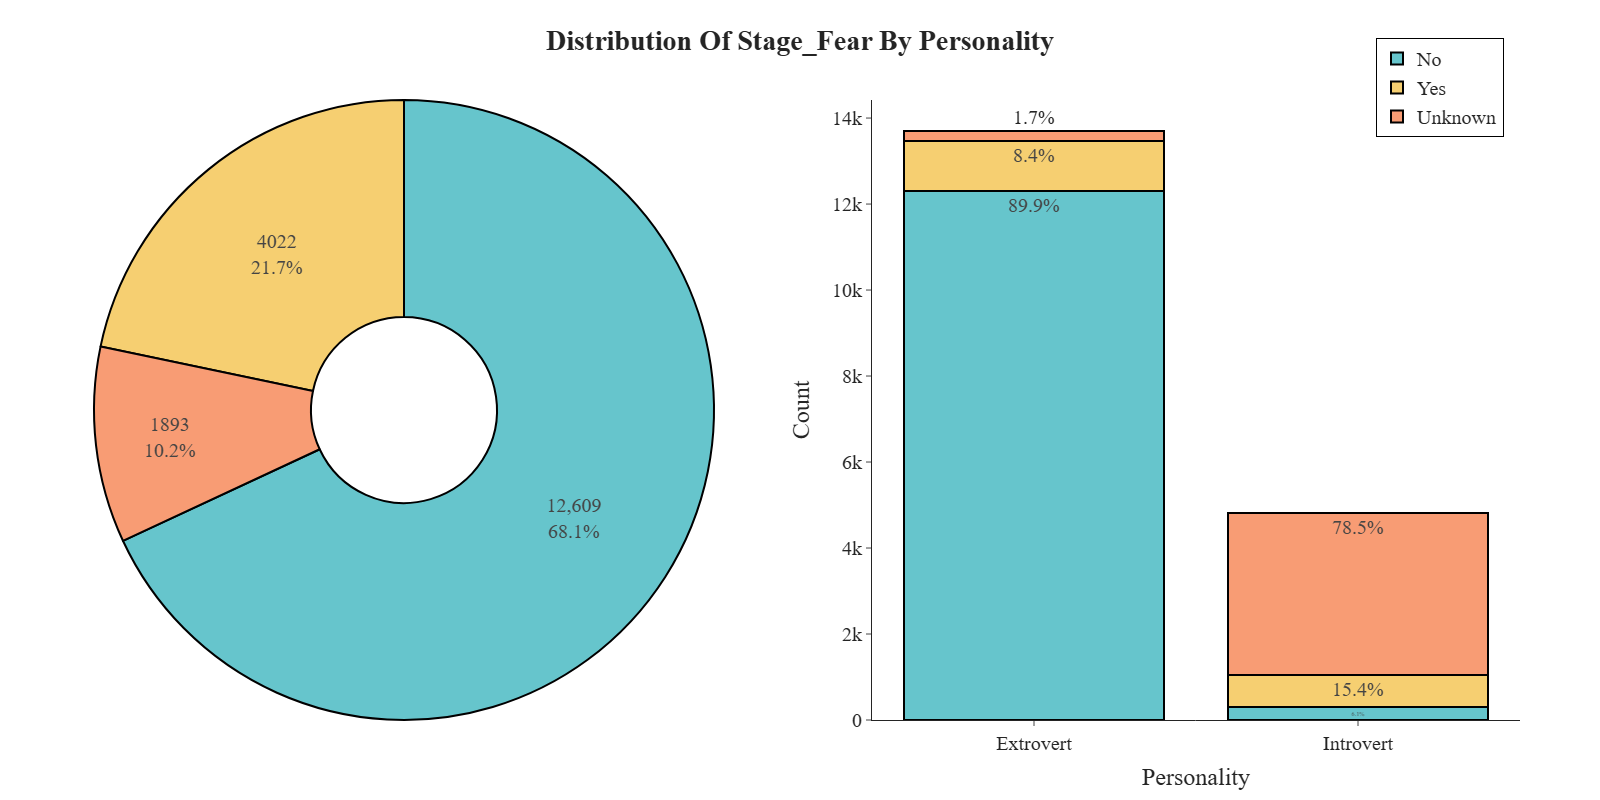

,Category,Count,Percentage (%)
0,No,"12,609",68.07%
1,Yes,"4,022",21.71%
2,Unknown,"1,893",10.22%


In [22]:
categorical_plots.pie_stacked_barplot_by_hue(train_data, 'Stage_fear', target_feature, plot_title=f"Distribution of Stage_fear by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, 'Stage_fear')

**Notes:**

**Conclusion:**

## `Social_event_attendance`

`Social_event_attendance` (float64) - The frequency or preference level for attending social gatherings, parties, or group events, measured on a numerical scale.

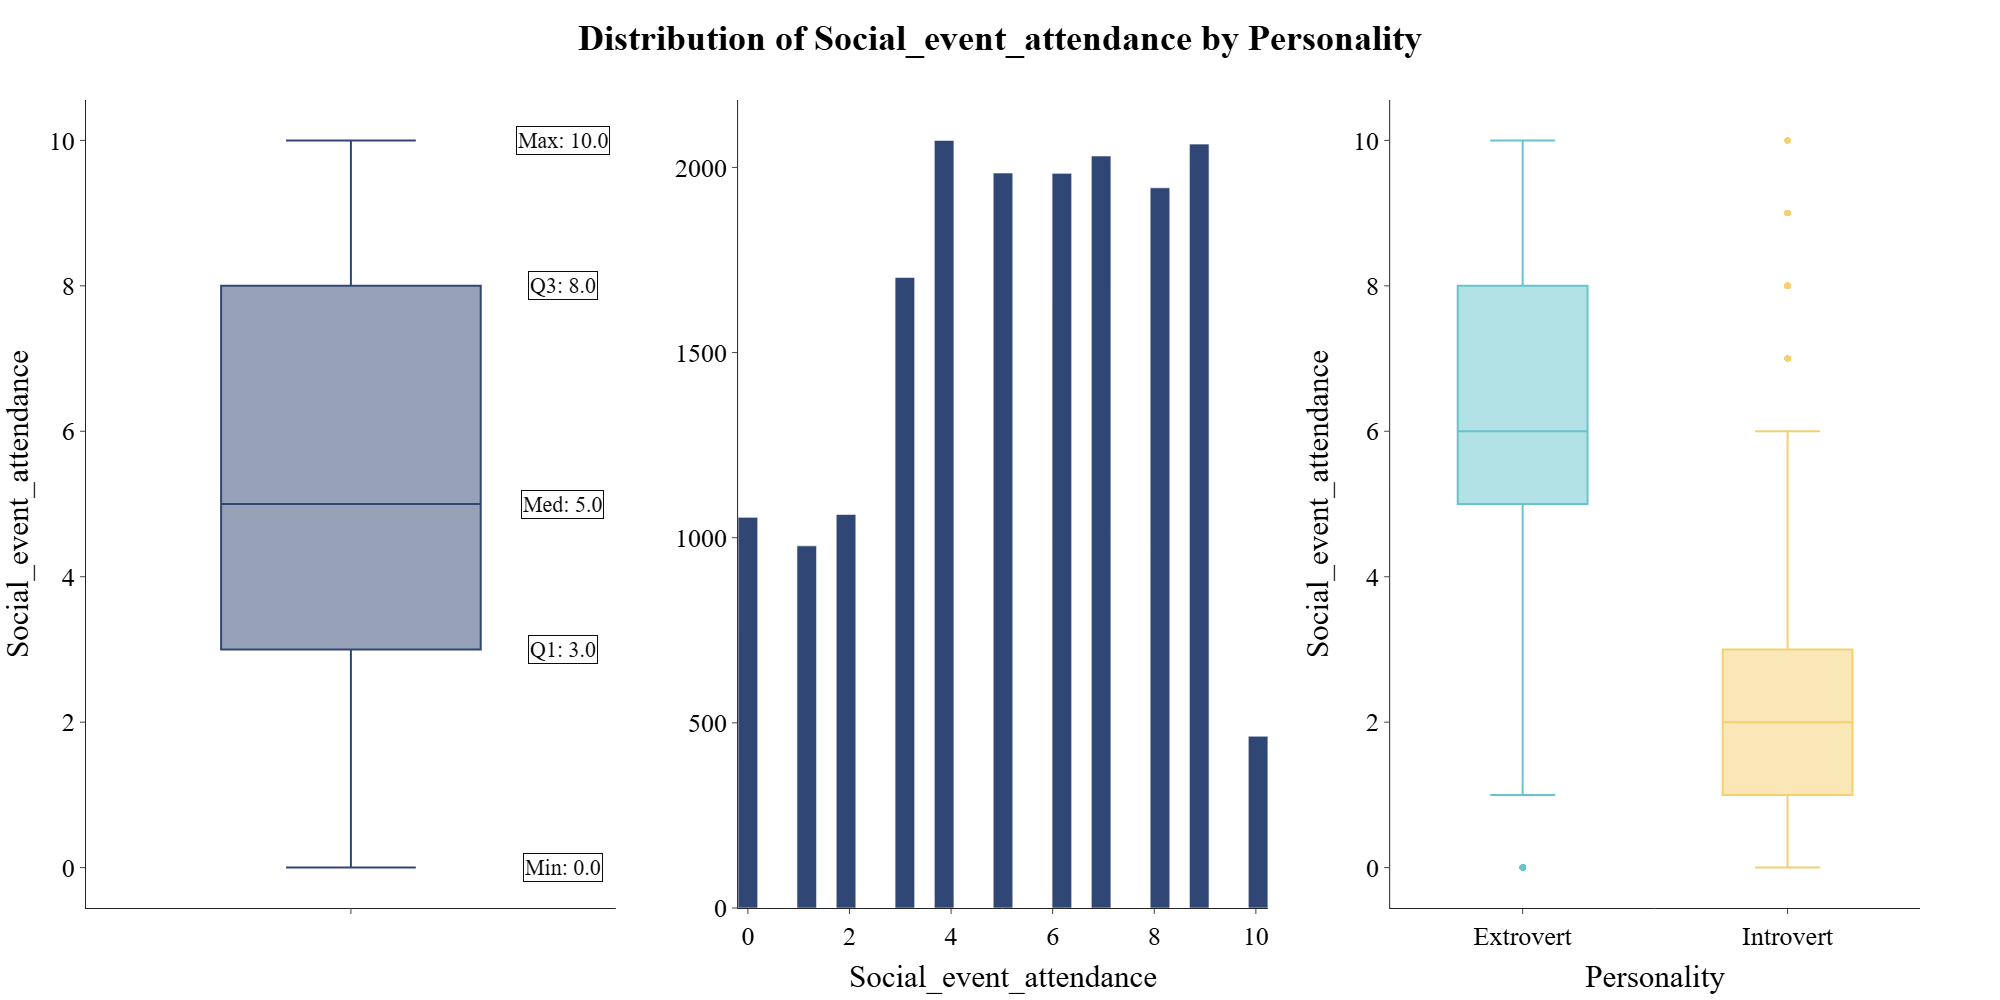

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Social_event_attendance,"17,344",5.27,2.75,0.00,0.00,3.00,5.00,8.00,9.00,10.00,7.58,-0.23,-0.93


In [23]:
continuous_plots.boxplot_histogram_boxplot_by_hue(train_data, 'Social_event_attendance', target_feature, plot_title=f"Distribution of Social_event_attendance by {target_feature}")
data_analyzer.describe_numerical_feature(train_data, 'Social_event_attendance')

**Notes:**

**Conclusion:**

## `Going_outside`

`Going_outside` (float64) - The frequency or preference for outdoor activities and leaving one's home environment, measured on a numerical scale.

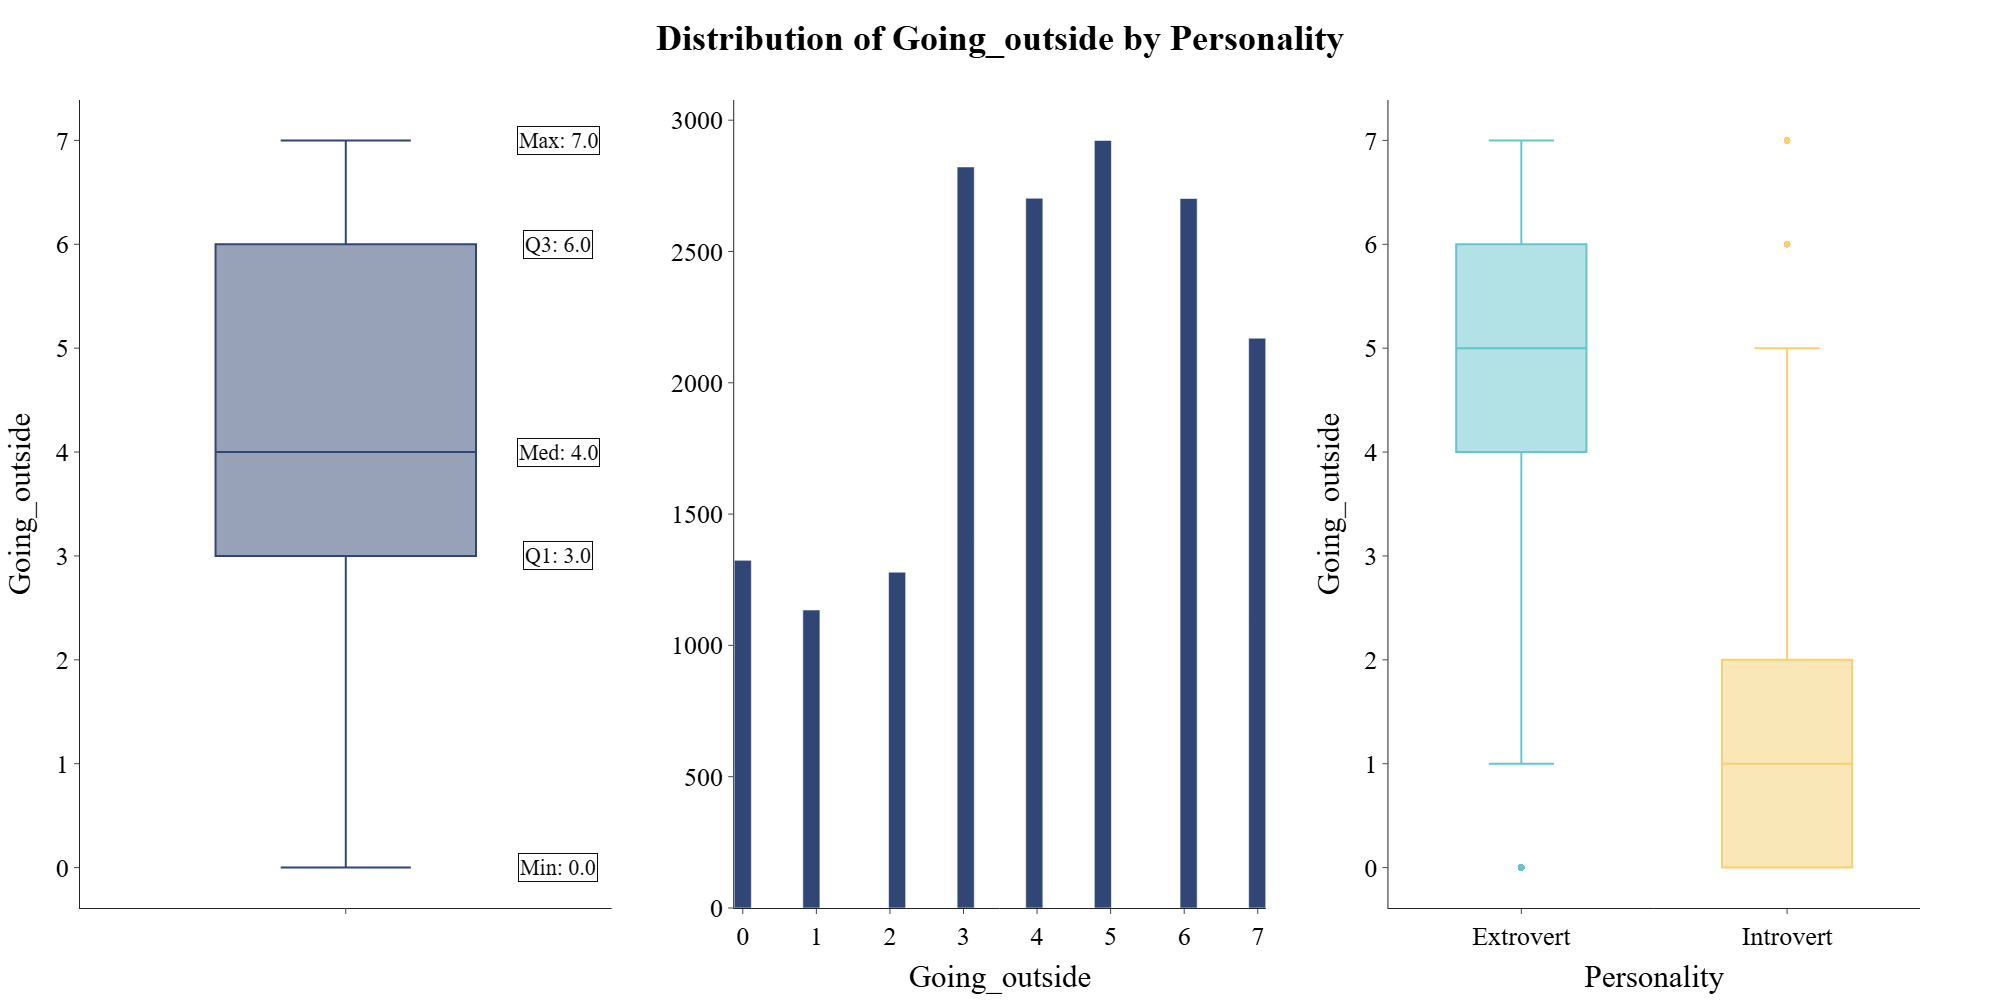

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Going_outside,"17,058",4.04,2.06,0.00,0.00,3.00,4.00,6.00,7.00,7.00,4.25,-0.37,-0.78


In [24]:
continuous_plots.boxplot_histogram_boxplot_by_hue(train_data, 'Going_outside', target_feature, plot_title=f"Distribution of Going_outside by {target_feature}")
data_analyzer.describe_numerical_feature(train_data, 'Going_outside')

**Notes:**

**Conclusion:**

## `Drained_after_socializing`

`Drained_after_socializing` (category) - Whether the person feels emotionally or physically drained after social interactions (Yes/No/Unknown).

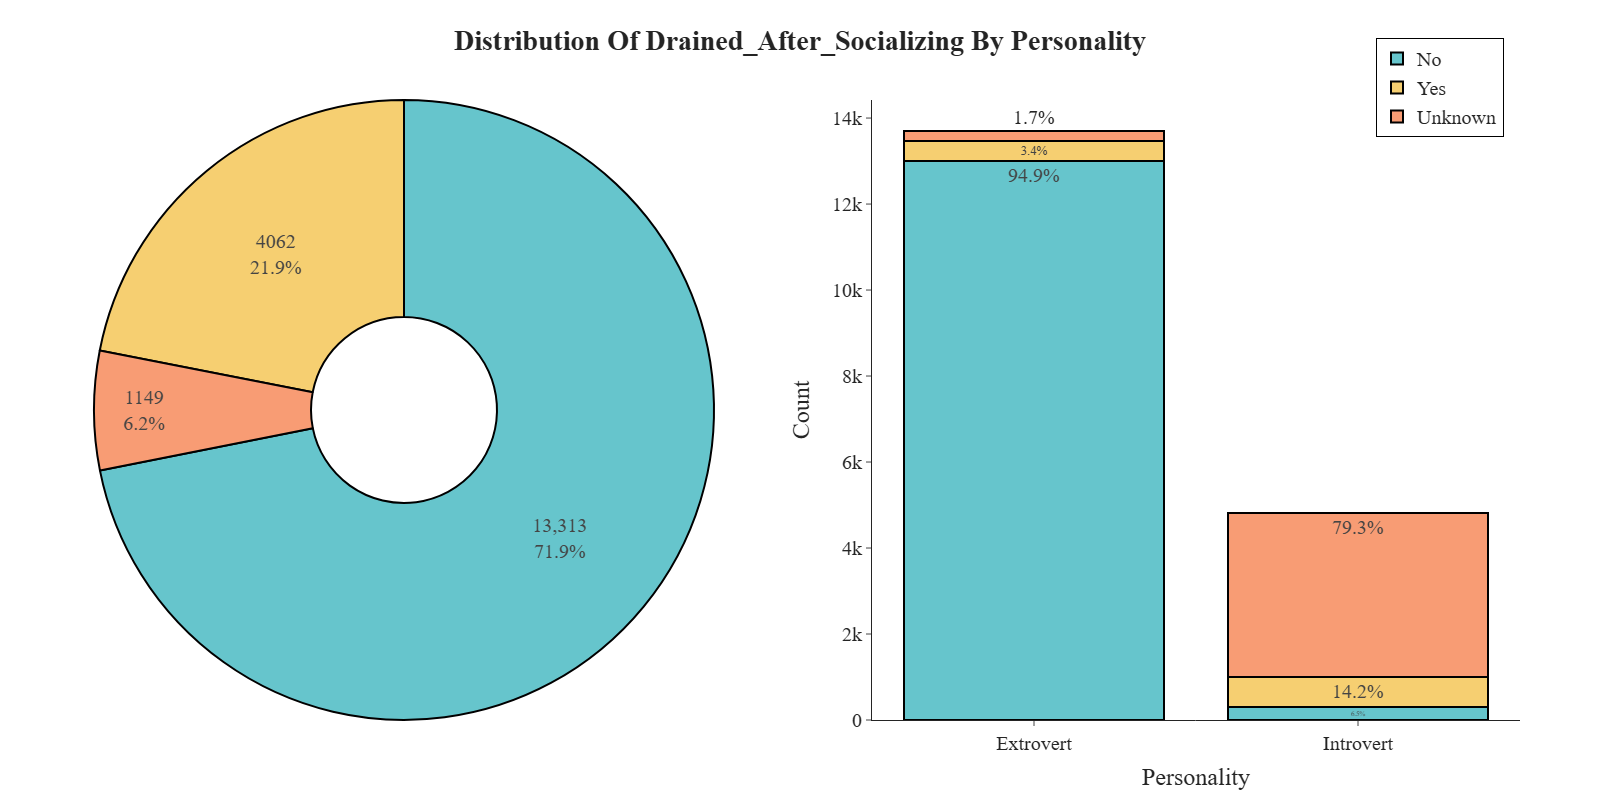

,Category,Count,Percentage (%)
0,No,"13,313",71.87%
1,Yes,"4,062",21.93%
2,Unknown,"1,149",6.20%


In [25]:
categorical_plots.pie_stacked_barplot_by_hue(train_data, 'Drained_after_socializing', target_feature, plot_title=f"Distribution of Drained_after_socializing by {target_feature}")
data_analyzer.describe_categorical_feature(train_data, 'Drained_after_socializing')

**Notes:**

**Conclusion:**

## `Friends_circle_size`

`Friends_circle_size` (float64) - The number of close friends or the size of one's social network, measured numerically.

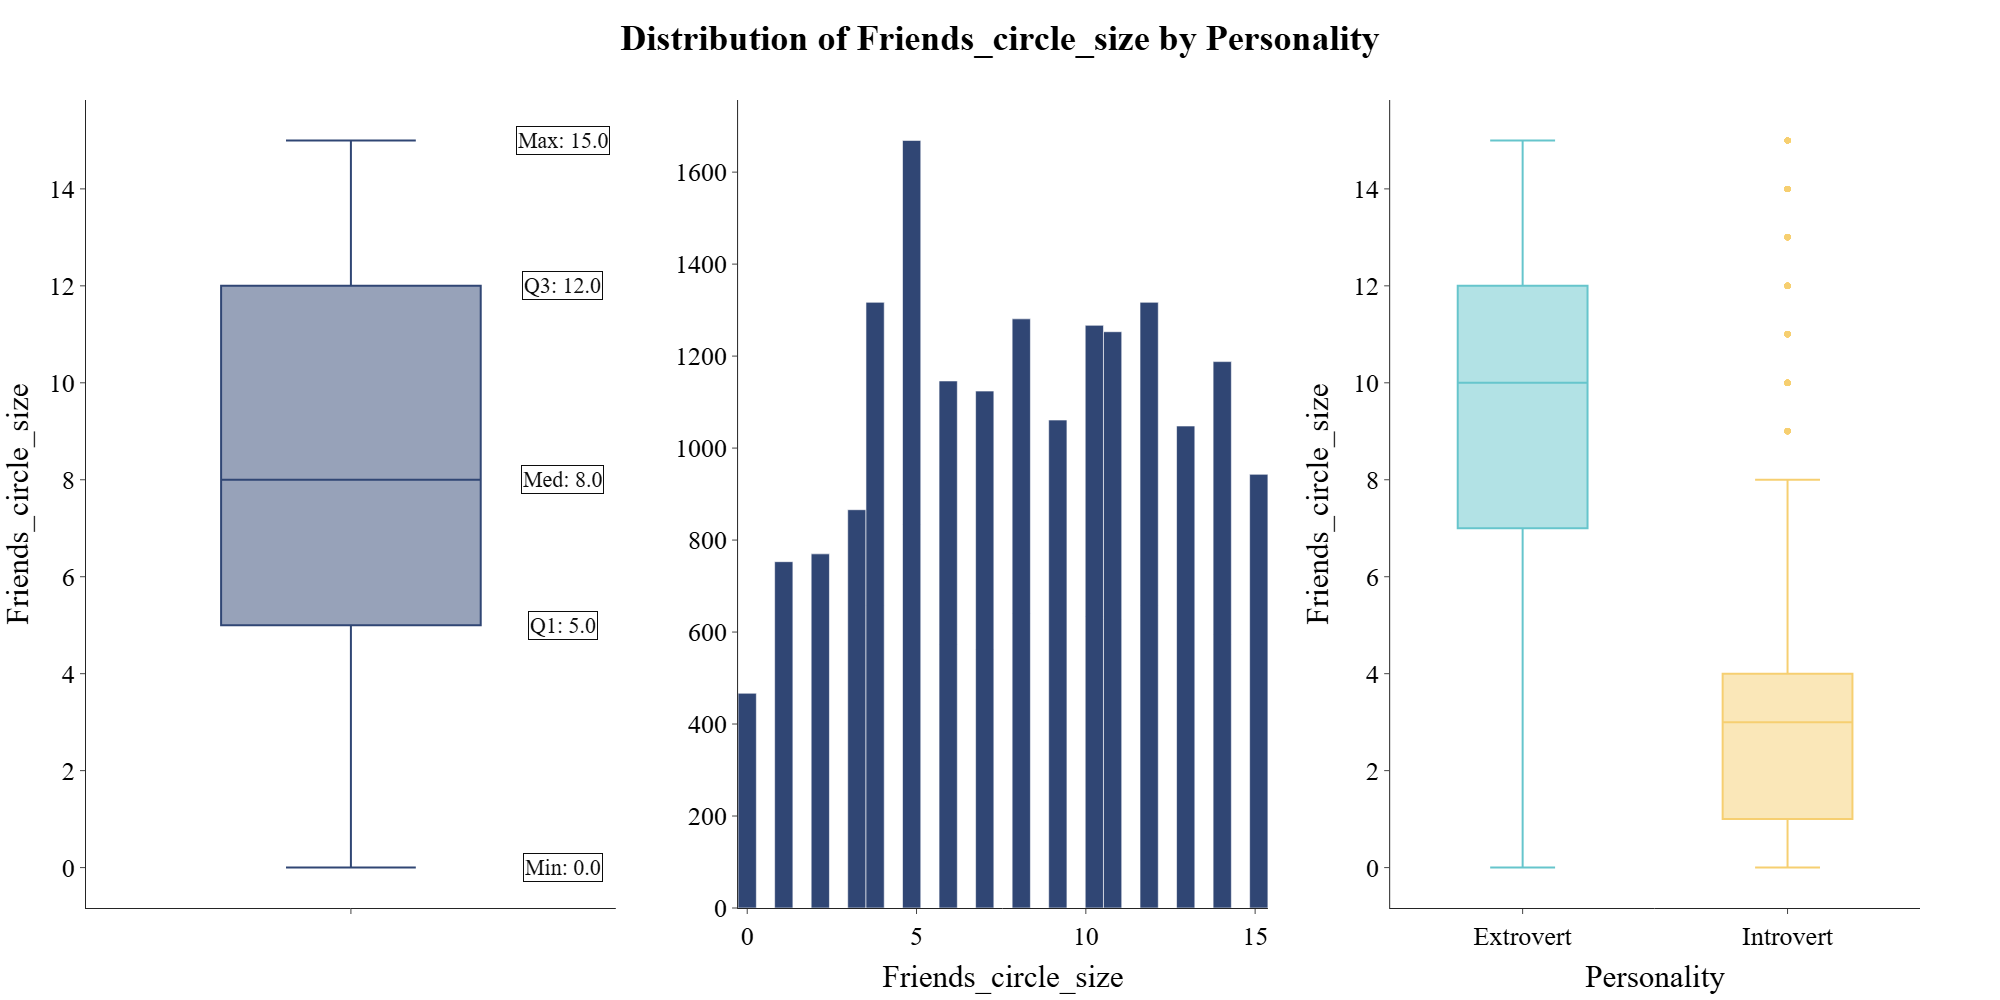

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Friends_circle_size,"17,470",8.00,4.22,0.00,1.00,5.00,8.00,12.00,15.00,15.00,17.84,-0.05,-1.08


In [26]:
continuous_plots.boxplot_histogram_boxplot_by_hue(train_data, 'Friends_circle_size', target_feature, plot_title=f"Distribution of Friends_circle_size by {target_feature}")
data_analyzer.describe_numerical_feature(train_data, 'Friends_circle_size')

**Notes:**

**Conclusion:**

## `Post_frequency`

`Post_frequency` (float64) - How often the person posts content on social media platforms, measured on a frequency scale.

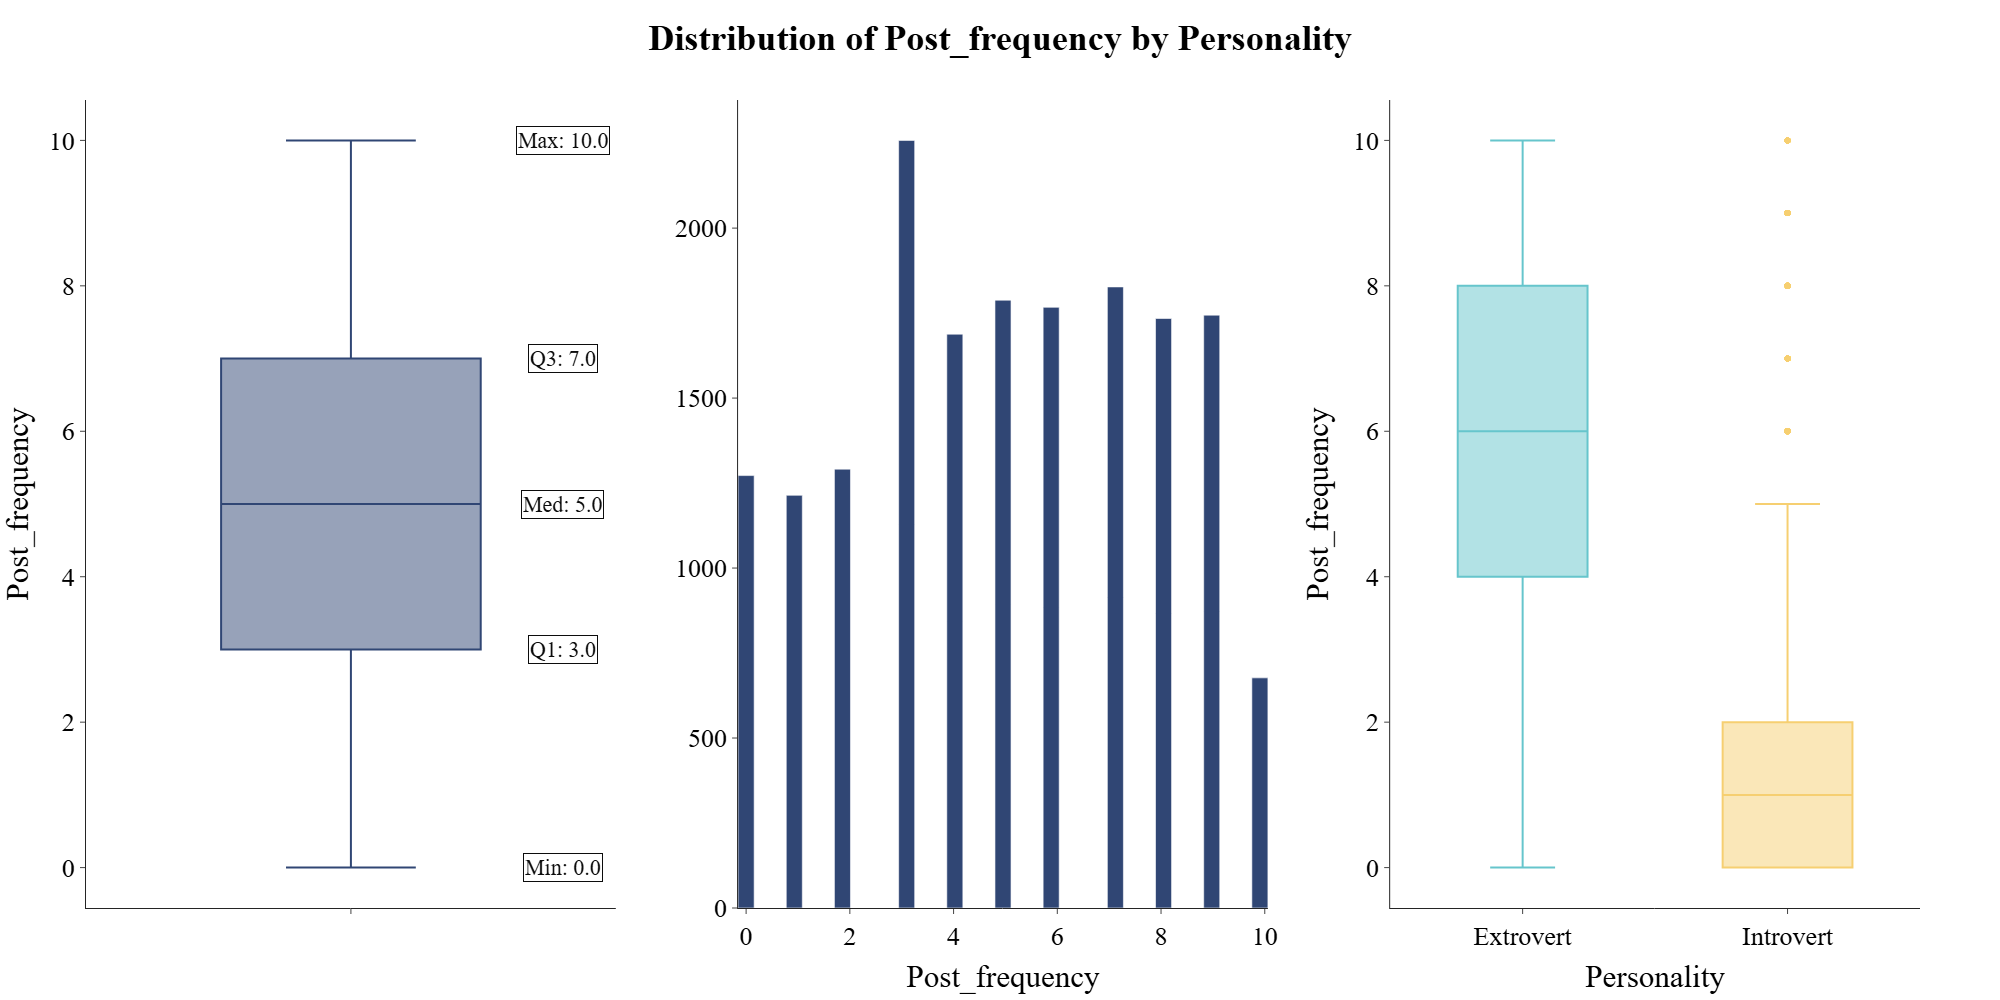

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis
Post_frequency,"17,260",4.98,2.88,0.00,0.00,3.00,5.00,7.00,9.00,10.00,8.29,-0.06,-1.07


In [27]:
continuous_plots.boxplot_histogram_boxplot_by_hue(train_data, 'Post_frequency', target_feature, plot_title=f"Distribution of Post_frequency by {target_feature}")
data_analyzer.describe_numerical_feature(train_data, 'Post_frequency')

**Notes:**

**Conclusion:**

# Feature Engineering

## Target encoding

In [28]:
train_data, id2label = data_transformer.encode_target_feature(train_data, target_feature=target_feature, verbose=True)


Target Feature Analysis: 'Personality'
• Total unique classes: 2
• Class mappings:
  1. Label 'Extrovert' → Encoded as 0
  2. Label 'Introvert' → Encoded as 1


## Custom Feature Generation

In [ ]:
def custom_features_generation_before_preprocessing(
    df: pd.DataFrame
) -> pd.DataFrame:
    """
    Add custom features before applying preprocessing steps.

    Args:
        df (pd.DataFrame): DataFrame to which custom features will be added.

    Returns:
        pd.DataFrame: DataFrame with custom features added.
    """
    df['time_alone_high'] = (df['Time_spent_Alone'] > 5).astype("category")
    df['time_alone_low'] = (df['Time_spent_Alone'] < 3).astype("category")
    df['high_social_attendance'] = (df['Social_event_attendance'] > 5).astype("category")
    df['frequent_outdoor'] = (df['Going_outside'] > 4).astype("category")
    df['large_friend_circle'] = (df['Friends_circle_size'] > 7).astype("category")
    df['frequent_poster'] = (df['Post_frequency'] > 5).astype("category")
    return df

steps = [
    CrossFeatureGenerator(features_names=[], degree=2),
    TargetEncodingFeatureGenerator(
        features_names=[],
        aggregation="mean",
        smooth=10,
        cv=KFold(n_splits=5, shuffle=True, random_state=17),
    ),
    CountEncodingFeatureGenerator(features_names=[], fill_value=0),
]

feature_generation_pipeline = FeatureGenerationPipeline(
    features_names=list(set(train_data.columns) - {target_feature}),
    preprocessing_steps=steps,
    custom_features_generation_before_preprocessing=custom_features_generation_before_preprocessing,
)

X_train = train_data.drop(columns=[target_feature])
y_train = train_data[target_feature]
X_test = test_data.drop(columns=[target_feature], errors='ignore')

X_train = feature_generation_pipeline.fit_transform(X=X_train, y=y_train)
X_test = feature_generation_pipeline.transform(X=X_test)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = X_test.copy()
train_data.head()

Transforming with count encoding: 100%|██████████| 78/78 [00:00<00:00, 4105.25it/s]


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,time_alone_high,time_alone_low,high_social_attendance,...,CE_frequent_poster-large_friend_circle,CE_frequent_poster-time_alone_high,CE_frequent_poster-time_alone_low,CE_high_social_attendance-large_friend_circle,CE_high_social_attendance-time_alone_high,CE_high_social_attendance-time_alone_low,CE_large_friend_circle-time_alone_high,CE_large_friend_circle-time_alone_low,CE_time_alone_high-time_alone_low,Personality
0,0.0,No,6.0,4.0,No,15.0,5.0,False,True,True,...,4127,7434,4048,5856,8427,5530,9279,6111,9151,0
1,1.0,No,7.0,3.0,No,10.0,8.0,False,True,True,...,5231,7700,5103,5856,8427,5530,9279,6111,9151,0
2,6.0,Yes,1.0,0.0,Unknown,3.0,0.0,True,False,False,...,6648,3341,6727,6535,3330,6416,3311,6126,3390,1
3,3.0,No,7.0,3.0,No,11.0,5.0,False,False,True,...,4127,7434,6727,5856,8427,2957,9279,3247,5983,0
4,1.0,No,4.0,4.0,No,13.0,NaN,False,True,False,...,4127,7434,4048,3502,6707,3621,9279,6111,9151,0


### Clean data if there are some redundant features

In [30]:
train_data = data_cleaner.initial_features_removal(train_data)
train_data = data_cleaner.drop_highly_skewed_categorical_features(train_data, features_to_investigate=train_data.drop(columns=[target_feature]).columns.tolist(), threshold=0.99)

Features Time_spent_Alone-time_alone_high and Time_spent_Alone-time_alone_low are identical. Removing the feature: Time_spent_Alone-time_alone_low
Features TE_MEAN_Time_spent_Alone-time_alone_high and TE_MEAN_Time_spent_Alone-time_alone_low are identical. Removing the feature: TE_MEAN_Time_spent_Alone-time_alone_low
Features CE_Time_spent_Alone-time_alone_high and CE_Time_spent_Alone-time_alone_low are identical. Removing the feature: CE_Time_spent_Alone-time_alone_low

Number of features after removal: 245. Removed 3 features.


## Dtypes conversion (memory optimization)

In [31]:
categorical_features = data_analyzer.get_categorical_features(train_data, unique_threshold=100)
independent_features = list(set(train_data.columns) - {target_feature})
print("Train data memory optimization:")
train_data = data_transformer.optimize_memory(train_data, categorical_features=categorical_features, verbose=True)
print("\nTest data memory optimization:")
test_data = data_transformer.optimize_memory(test_data, categorical_features=categorical_features, verbose=True)
if target_feature in categorical_features:
    categorical_features.remove(target_feature)
    train_data[target_feature] = train_data[target_feature].cat.codes

Train data memory optimization:
Numerical dtypes reduced: 17.19 MB → 10.16 MB (40.9% reduction)
Categorical dtypes converted: 10.16 MB → 10.16 MB (-0.0% reduction)
Total memory usage reduced: 17.19 MB → 10.16 MB (40.9% reduction)

Test data memory optimization:
Numerical dtypes reduced: 5.84 MB → 3.46 MB (40.7% reduction)
Categorical dtypes converted: 3.46 MB → 3.46 MB (-0.0% reduction)
Total memory usage reduced: 5.84 MB → 3.46 MB (40.7% reduction)


# Summary of data analysis

In [32]:
data_analyzer.base_information(train_data)

,Feature,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,Time_spent_Alone,float32,"1,190",6.42%,12,"17,334"
1,Stage_fear,category,0,0.00%,3,"18,524"
2,Social_event_attendance,float32,"1,180",6.37%,11,"17,344"
3,Going_outside,float32,"1,466",7.91%,8,"17,058"
4,Drained_after_socializing,category,0,0.00%,3,"18,524"
5,Friends_circle_size,float32,"1,054",5.69%,16,"17,470"
6,Post_frequency,float32,"1,264",6.82%,11,"17,260"
7,time_alone_high,category,0,0.00%,2,"18,524"
8,time_alone_low,category,0,0.00%,2,"18,524"
9,high_social_attendance,category,0,0.00%,2,"18,524"


# Baseline modeling

### LightGBM

In [33]:
model = LGBMClassifier(boosting_type='gbdt', random_state=SEED, n_jobs=-1, objective='binary', metric='binary_logloss', verbose=-1, early_stopping=100)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9723 +- 0.0004
Validation Accuracy: 0.9690 +- 0.0019


### LightGBM (goss)

In [34]:
model = LGBMClassifier(boosting_type='goss', random_state=SEED, n_jobs=-1, objective='binary', metric='binary_logloss', verbose=-1, early_stopping=100)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9728 +- 0.0005
Validation Accuracy: 0.9690 +- 0.0017


### XGBoost

In [35]:
model = XGBClassifier(booster="gbtree", random_state=SEED, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', enable_categorical=True, tree_method='hist', verbosity=0, early_stopping_rounds=100)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9734 +- 0.0004
Validation Accuracy: 0.9686 +- 0.0021


### Histogram-based Gradient Boosting

In [36]:
model = HistGradientBoostingClassifier(random_state=SEED, categorical_features=categorical_features, early_stopping=True, scoring='neg_log_loss', max_iter=1000, verbose=0)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9733 +- 0.0013
Validation Accuracy: 0.9692 +- 0.0023


### CatBoost

In [37]:
model = CatBoostClassifier(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='Logloss', eval_metric='Logloss', early_stopping_rounds=100, allow_writing_files=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9716 +- 0.0003
Validation Accuracy: 0.9692 +- 0.0021


## Ensemble model

In [38]:
estimators = [
    LGBMClassifier(boosting_type='gbdt', random_state=SEED, n_jobs=-1, objective='binary', metric='binary_logloss', verbose=-1, early_stopping=100),
    # LGBMClassifier(boosting_type='goss', random_state=SEED, n_jobs=-1, objective='binary', metric='binary_logloss', verbose=-1, early_stopping=100),
    XGBClassifier(booster="gbtree", random_state=SEED, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', enable_categorical=True, tree_method='hist', verbosity=0, early_stopping_rounds=100),
    # HistGradientBoostingClassifier(random_state=SEED, categorical_features=categorical_features, early_stopping=True, scoring='roc_auc', verbose=0),
    # CatBoostClassifier(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='Logloss', eval_metric='Logloss', early_stopping_rounds=100, allow_writing_files=False)
]
ensemble_model = EnsembleModel(estimators=estimators, problem_type=PROBLEM_TYPE)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9727 +- 0.0003
Validation Accuracy: 0.9689 +- 0.0021


# Feature selection

## Shape RFE

🔍 Starting SHAP-RFE with 244 features, target metric: Accuracy (maximize), steps: 50.
📅 The number of features to remove every step: [8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2]

🔁 Step 1 | Features remaining: 244
📊 Average Accuracy: 0.968905 ± 0.002057

🔁 Step 2 | Features remaining: 236
📊 Average Accuracy: 0.968797 ± 0.001943

🔁 Step 3 | Features remaining: 228
📊 Average Accuracy: 0.969013 ± 0.001701

🔁 Step 4 | Features remaining: 220
📊 Average Accuracy: 0.969067 ± 0.001745

🔁 Step 5 | Features remaining: 212
📊 Average Accuracy: 0.969013 ± 0.002147

🔁 Step 6 | Features remaining: 204
📊 Average Accuracy: 0.969553 ± 0.001872

🔁 Step 7 | Features remaining: 197
📊 Average Accuracy: 0.969337 ± 0.001711

🔁 Step 8 | Features remaining: 190
📊 Average Accuracy: 0.969499 ± 0.001922

🔁 Step 9 | Features remaining: 183
📊 Average Accuracy: 0.969229 ± 0.002083

🔁 Step 10 | Features remaining:

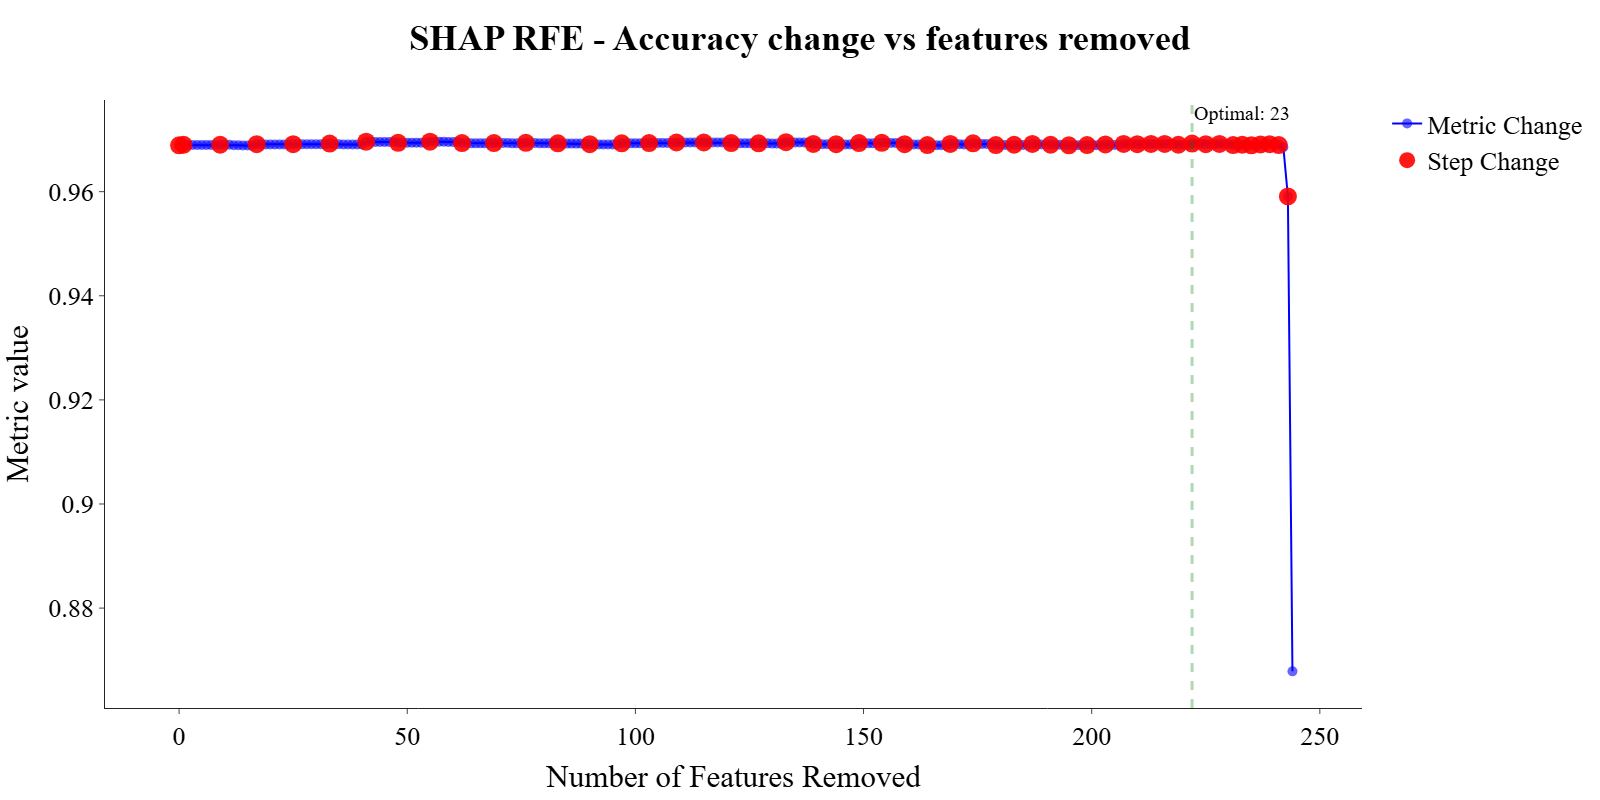

In [39]:
shap_rfe = ShapRecursiveFeatureElimination(
    estimator=ensemble_model,
    cross_validator=cross_validation_trainer,
    problem_type=PROBLEM_TYPE,
    steps=50,
    alpha=0.99,
    verbose=True
)
shap_rfe_summary = shap_rfe.run(train_data[independent_features], train_data[target_feature])
other_plots.plot_metric_change_vs_features_removed(shap_rfe_summary["history"], optimal_n_features=len(shap_rfe_summary["selected_features"]), plot_title=f"SHAP RFE - {METRIC_NAME} change vs features removed")

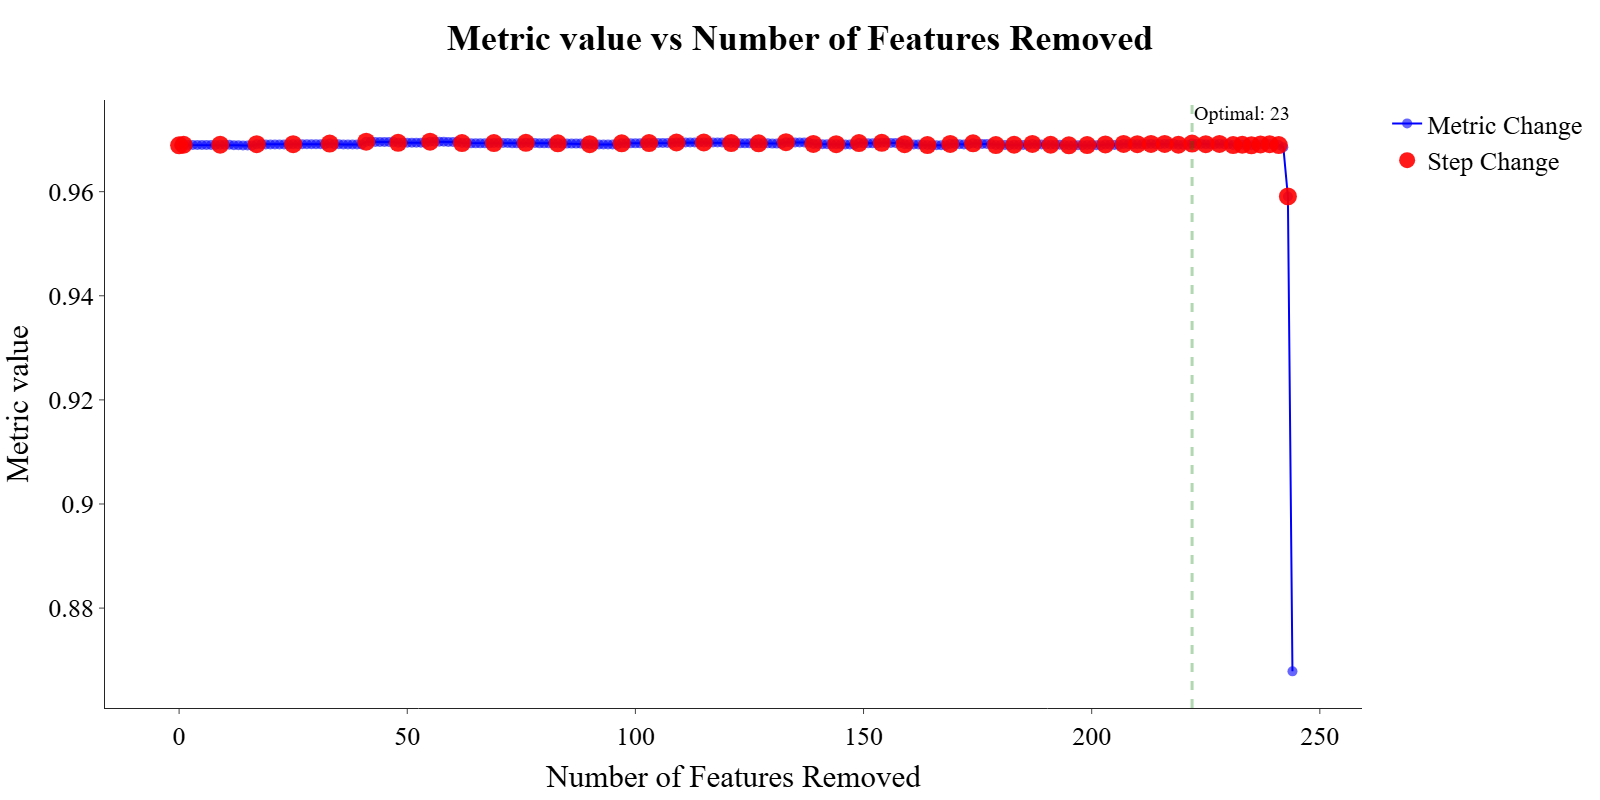

Number of features selected: 23
Selected features: ['TE_MEAN_Drained_after_socializing-frequent_outdoor', 'Going_outside-large_friend_circle', 'CE_frequent_outdoor-frequent_poster', 'TE_MEAN_Social_event_attendance-Stage_fear', 'CE_high_social_attendance-time_alone_high', 'Drained_after_socializing', 'CE_frequent_poster-time_alone_low', 'CE_Drained_after_socializing-time_alone_high', 'Stage_fear', 'TE_MEAN_Drained_after_socializing-Time_spent_Alone', 'CE_frequent_poster-large_friend_circle', 'frequent_poster-time_alone_high', 'large_friend_circle-time_alone_low', 'CE_large_friend_circle-time_alone_high', 'frequent_outdoor-time_alone_low', 'TE_MEAN_Post_frequency-Time_spent_Alone', 'high_social_attendance', 'time_alone_high', 'CE_frequent_outdoor-large_friend_circle', 'time_alone_high-time_alone_low', 'CE_large_friend_circle-time_alone_low', 'TE_MEAN_frequent_poster-time_alone_low', 'TE_MEAN_Drained_after_socializing-Stage_fear']
Accuracy after feature selection: 0.969229


In [40]:
selected_features, metric_value = shap_rfe.select_features_weighted_score(shap_rfe_summary["history"], alpha=0.99)
other_plots.plot_metric_change_vs_features_removed(shap_rfe_summary["history"], optimal_n_features=len(selected_features))
print(f"Number of features selected: {len(selected_features)}")
print(f"Selected features: {selected_features}")
print(f"{METRIC_NAME} after feature selection: {metric_value:.6f}")

In [41]:
selected_features = ['Stage_fear-large_friend_circle', 'TE_MEAN_Social_event_attendance-Stage_fear', 'CE_large_friend_circle-time_alone_high', 'CE_Stage_fear-frequent_poster', 'Drained_after_socializing-time_alone_low', 'TE_MEAN_Time_spent_Alone-time_alone_high', 'CE_Drained_after_socializing-high_social_attendance', 'CE_Drained_after_socializing-Post_frequency', 'CE_Stage_fear-large_friend_circle', 'CE_Stage_fear-high_social_attendance', 'CE_Drained_after_socializing-large_friend_circle', 'Drained_after_socializing-frequent_poster', 'CE_Stage_fear-time_alone_high', 'frequent_poster-time_alone_high', 'TE_MEAN_Post_frequency-Time_spent_Alone', 'large_friend_circle', 'CE_Friends_circle_size-Stage_fear', 'Stage_fear-high_social_attendance', 'time_alone_low', 'Stage_fear-time_alone_high', 'CE_frequent_outdoor-frequent_poster', 'CE_Friends_circle_size-large_friend_circle', 'Stage_fear', 'TE_MEAN_Drained_after_socializing-Time_spent_Alone', 'CE_frequent_poster-large_friend_circle', 'Stage_fear-frequent_poster', 'frequent_poster', 'TE_MEAN_Drained_after_socializing-Stage_fear', 'CE_time_alone_high-time_alone_low', 'CE_frequent_poster-time_alone_high', 'Drained_after_socializing']
# selected_features = shap_rfe_summary["selected_features"]

In [42]:
independent_features = selected_features.copy()
categorical_features = [feature for feature in independent_features if train_data[feature].dtype.name == 'category']
train_data = train_data[independent_features + [target_feature]]
test_data = test_data[independent_features]

In [43]:
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9710 +- 0.0004
Validation Accuracy: 0.9694 +- 0.0020


# Sampling

In [44]:
sampling_results = []

# 1. No sampling (baseline)
print("🔄 Testing baseline (no sampling)...")
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=None, verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
sampling_results.append({
    "Sampling": "None (Baseline)",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 2. SMOTE (Synthetic Minority Oversampling Technique)
print("\n🔄 Testing SMOTE...")
smote_sampler = SMOTENC(categorical_features=categorical_features, random_state=SEED)
mean_imputer = MeanMedianImputer(imputation_method='mean', variables=list(train_data[independent_features].select_dtypes(include=['number']).columns))
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[mean_imputer, smote_sampler], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
sampling_results.append({
    "Sampling": "SMOTE",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 3. Random Over Sampling
print("\n🔄 Testing Random Over Sampling...")
random_over_sampler = RandomOverSampler(random_state=SEED)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[mean_imputer, random_over_sampler], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
sampling_results.append({
    "Sampling": "Random Over Sampling",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

# 4. Random Under Sampling
print("\n🔄 Testing Random Under Sampling...")
random_under_sampler = RandomUnderSampler(random_state=SEED)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[mean_imputer, random_under_sampler], verbose=False)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
sampling_results.append({
    "Sampling": "Random Under Sampling",
    "Train Mean": np.mean(train_scores),
    "Train Std": np.std(train_scores),
    "Valid Mean": np.mean(valid_scores),
    "Valid Std": np.std(valid_scores)
})

sampling_results_df = pd.DataFrame(sampling_results)
sampling_results_df = sampling_results_df[["Sampling", "Train Mean", "Train Std", "Valid Mean", "Valid Std"]]
sampling_results_df.style.set_caption("📝 Sampling Comparison") \
    .format({
        "Train Mean": "{:.4f}",
        "Train Std": "{:.4f}",
        "Valid Mean": "{:.4f}",
        "Valid Std": "{:.4f}"
    }) \
    .bar(subset=["Valid Mean"], color="#4a90e2", vmin=0, vmax=1) \
    .set_properties(**{
        'text-align': 'left',
        'font-family': 'Times New Roman',
        'font-size': '1.25em',
        'background-color': '#f9f9f9',
        'border': '1px solid #ddd',
        'color': '#333'
    }) \
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('border', '1px solid #ddd')]}])

🔄 Testing baseline (no sampling)...
Train Accuracy: 0.9710 +- 0.0004
Validation Accuracy: 0.9694 +- 0.0020

🔄 Testing SMOTE...
Train Accuracy: 0.9759 +- 0.0017
Validation Accuracy: 0.9686 +- 0.0017

🔄 Testing Random Over Sampling...
Train Accuracy: 0.9658 +- 0.0010
Validation Accuracy: 0.9681 +- 0.0020

🔄 Testing Random Under Sampling...
Train Accuracy: 0.9625 +- 0.0009
Validation Accuracy: 0.9680 +- 0.0021


,Sampling,Train Mean,Train Std,Valid Mean,Valid Std
0,None (Baseline),0.9710,0.0004,0.9694,0.0020
1,SMOTE,0.9759,0.0017,0.9686,0.0017
2,Random Over Sampling,0.9658,0.0010,0.9681,0.0020
3,Random Under Sampling,0.9625,0.0009,0.9680,0.0021


In [45]:
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[mean_imputer, smote_sampler], verbose=False)
cross_validation_trainer = CrossValidationTrainer(metric_name = METRIC_NAME, problem_type=PROBLEM_TYPE, cv = CV, processors=[], verbose=False)

# Hyperparameter tuning

In [46]:
tuner = RandomSearchCV(cross_validator=cross_validation_trainer, n_trials=100, seed=SEED)

## LightGBM

In [47]:
model = LGBMClassifier()
constant_params_grid = {
    "boosting_type": ("constant", ["gbdt"]),
    "seed": ("constant", [SEED]),
    "verbose": ("constant", [-1]),
    "n_jobs": ("constant", [-1]),
    "early_stopping_rounds": ("constant", [100]),
}
constant_params_grid["objective"] = ("constant", ["binary"])

tunable_params_grid = {
    "n_estimators": ("int", [200, 2000], {"step": 50}),
    "learning_rate": ("float", [1e-4, 0.3], {"log": True}),
    "num_leaves": ("int", [15, 512], {"step": 1}),
    "max_depth": ("int", [-1, 30], {"step": 1}),
    "min_child_samples": ("int", [5, 300], {"step": 5}),
    "subsample": ("float", [0.4, 1.0], {"log": True}),
    "colsample_bytree": ("float", [0.4, 1.0], {"log": True}),
    "reg_alpha": ("float", [1e-4, 10.0], {"log": True}),
    "reg_lambda": ("float", [1e-4, 10.0], {"log": True}),
    "min_split_gain": ("float", [1e-4, 1.0], {"log": True}),
    "bagging_freq": ("int", [0, 10], {"step": 1}),
    "max_bin": ("int", [63, 511], {"step": 32}),
}
tunable_params_grid["metric"] = ("categorical", ["binary_logloss", "auc"])
tunable_params_grid["class_weight"] = ("categorical", ["balanced", None])

params_grid = {**constant_params_grid, **tunable_params_grid}

study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
lgbm_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
lgbm_best_params = {**constant_params, **lgbm_best_params}
print(lgbm_best_params)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\optuna\_experimental.py:31: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-08-16 13:29:41,712] A new study created in memory with name: Optuna tuning
[I 2025-08-16 13:29:54,898] Trial 0 finished with value: 0.9229673140318815 and parameters: {'n_estimators': 700, 'learning_rate': 0.0069970420741033885, 'num_leaves': 110, 'max_depth': 1, 'min_child_samples': 240, 'subsample': 0.7298630181242587, 'colsample_bytree': 0.7173895765627012, 'reg_alpha': 0.07551173844071643, 'reg_lambda': 0.00015678863564170368, 'min_split_gain': 0.002699320282307521, 'bagging_freq': 10, 'max_bin': 63, 'metric': 'auc', 'class_weight': None}. Best is trial 0 with value: 0.9229673140318815.
[I 2025-08-16 13:30:02,003] Trial 1 finished with value: 0.9692291952676175 and parameters: {'n_estimators': 1200, 'learning_rate': 0.01195710472037679, 'num_leaves': 255, 'max_depth': 8, 

{'boosting_type': 'gbdt', 'seed': 17, 'verbose': -1, 'n_jobs': -1, 'early_stopping_rounds': 100, 'objective': 'binary', 'n_estimators': 1950, 'learning_rate': 0.09764098635590902, 'num_leaves': 41, 'max_depth': 22, 'min_child_samples': 25, 'subsample': 0.7058192571988156, 'colsample_bytree': 0.4001543078918441, 'reg_alpha': 0.6667458772180266, 'reg_lambda': 0.010098944003558761, 'min_split_gain': 0.00015469462790299816, 'bagging_freq': 6, 'max_bin': 159, 'metric': 'binary_logloss', 'class_weight': None}


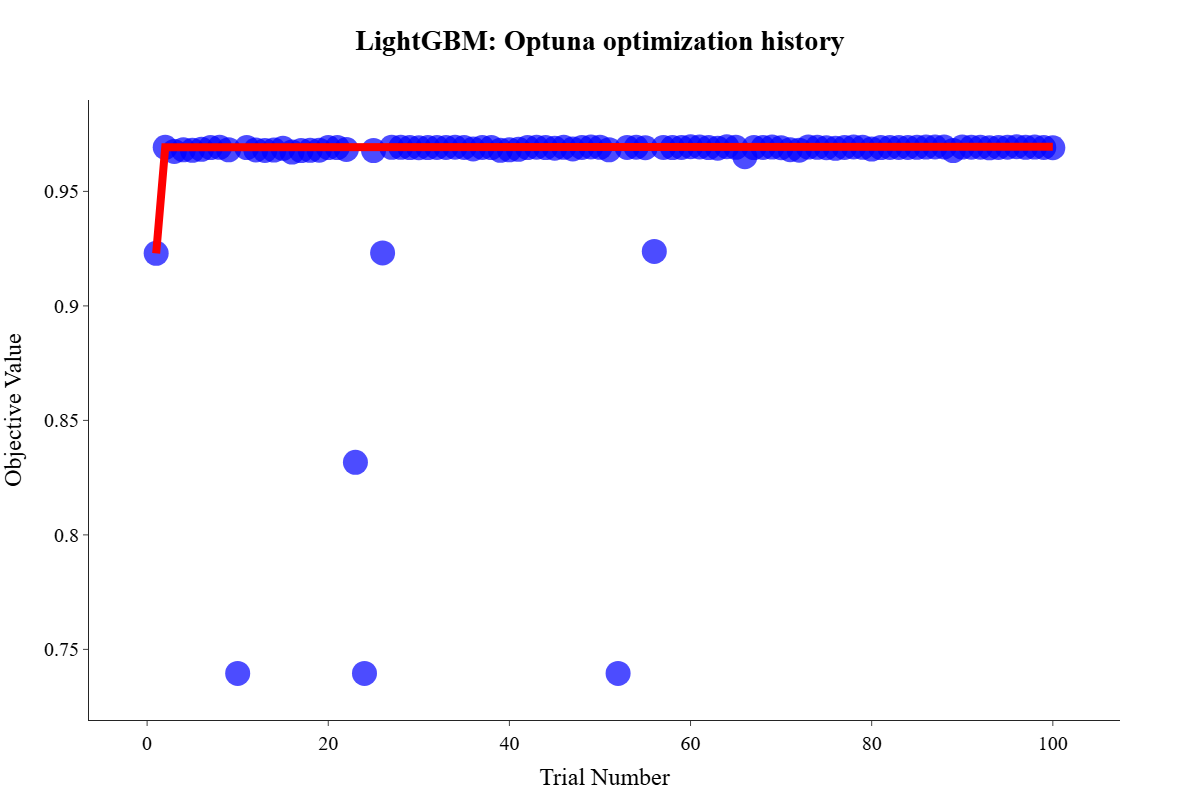

In [48]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="LightGBM: Optuna optimization history", direction=METRICS[METRIC_NAME][2])

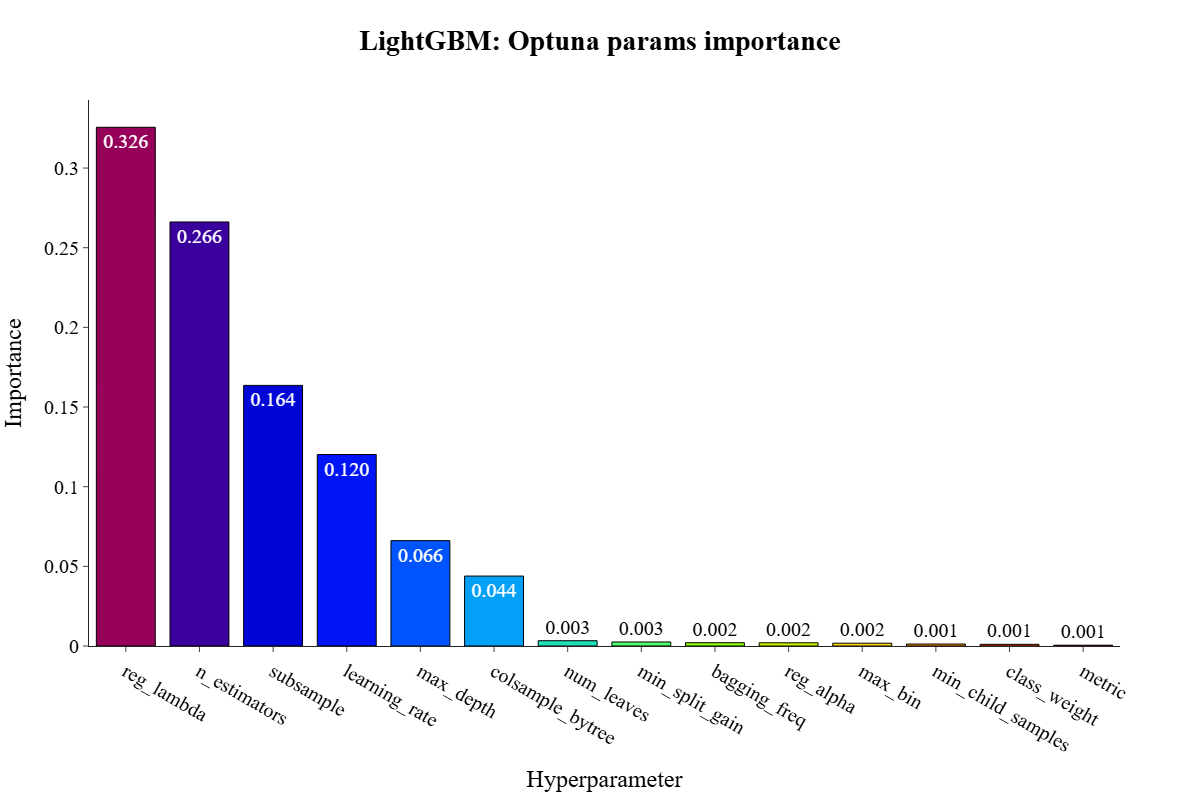

In [49]:
optuna_plots.plot_optuna_param_importance(study, plot_title="LightGBM: Optuna params importance")

In [50]:
model = LGBMClassifier(**lgbm_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9700 +- 0.0005
Validation Accuracy: 0.9696 +- 0.0018


## LightGBM (goss)

In [51]:
model = LGBMClassifier()
constant_params_grid = {
    "boosting_type": ("constant", ["goss"]),
    "seed": ("constant", [SEED]),
    "verbose": ("constant", [-1]),
    "n_jobs": ("constant", [-1]),
    "early_stopping_rounds": ("constant", [100]),
}
constant_params_grid["objective"] = ("constant", ["binary"])

tunable_params_grid = {
    "n_estimators": ("int", [200, 2000], {"step": 50}),
    "learning_rate": ("float", [1e-4, 0.3], {"log": True}),
    "num_leaves": ("int", [15, 512], {"step": 1}),
    "max_depth": ("int", [-1, 30], {"step": 1}),
    "min_child_samples": ("int", [5, 300], {"step": 5}),
    "subsample": ("float", [0.4, 1.0], {"log": True}),
    "colsample_bytree": ("float", [0.4, 1.0], {"log": True}),
    "reg_alpha": ("float", [1e-4, 10.0], {"log": True}),
    "reg_lambda": ("float", [1e-4, 10.0], {"log": True}),
    "min_split_gain": ("float", [1e-4, 1.0], {"log": True}),
    "max_bin": ("int", [63, 511], {"step": 32}),
}
tunable_params_grid["metric"] = ("categorical", ["binary_logloss", "auc"])
tunable_params_grid["class_weight"] = ("categorical", ["balanced", None])

params_grid = {**constant_params_grid, **tunable_params_grid}

study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
lgbm_goss_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
lgbm_goss_best_params = {**constant_params, **lgbm_goss_best_params}
print(lgbm_goss_best_params)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\optuna\_experimental.py:31: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-08-16 13:42:50,535] A new study created in memory with name: Optuna tuning
[I 2025-08-16 13:43:05,331] Trial 0 finished with value: 0.9682034085046475 and parameters: {'n_estimators': 700, 'learning_rate': 0.0069970420741033885, 'num_leaves': 110, 'max_depth': 1, 'min_child_samples': 240, 'subsample': 0.7298630181242587, 'colsample_bytree': 0.7173895765627012, 'reg_alpha': 0.07551173844071643, 'reg_lambda': 0.00015678863564170368, 'min_split_gain': 0.002699320282307521, 'max_bin': 511, 'metric': 'auc', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9682034085046475.
[I 2025-08-16 13:43:12,959] Trial 1 finished with value: 0.9683654829880817 and parameters: {'n_estimators': 1400, 'learning_rate': 0.008289081528033058, 'num_leaves': 312, 'max_depth': 14, 'min_child_

{'boosting_type': 'goss', 'seed': 17, 'verbose': -1, 'n_jobs': -1, 'early_stopping_rounds': 100, 'objective': 'binary', 'n_estimators': 1650, 'learning_rate': 0.003728244759652633, 'num_leaves': 234, 'max_depth': 3, 'min_child_samples': 105, 'subsample': 0.5095950847170173, 'colsample_bytree': 0.7314397547043163, 'reg_alpha': 0.004454673579880087, 'reg_lambda': 0.003938507414610491, 'min_split_gain': 0.001681152419883116, 'max_bin': 63, 'metric': 'binary_logloss', 'class_weight': None}


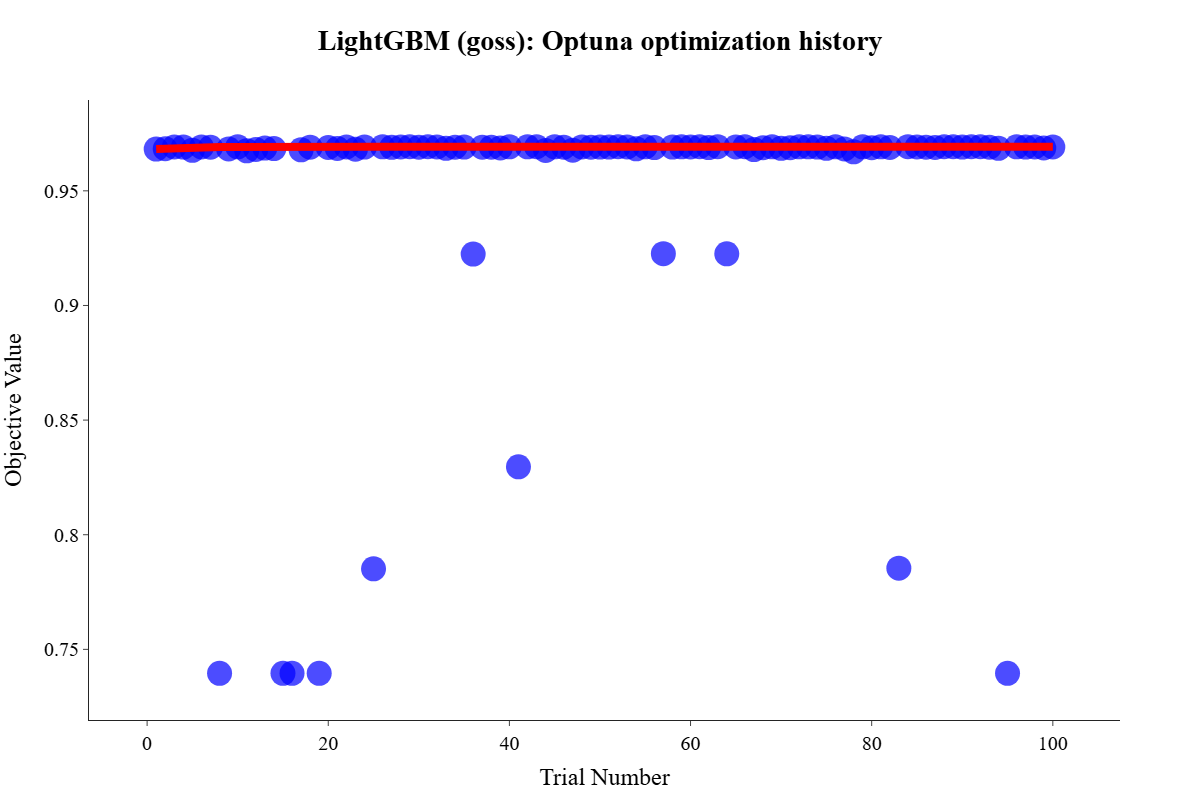

In [52]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="LightGBM (goss): Optuna optimization history", direction=METRICS[METRIC_NAME][2])

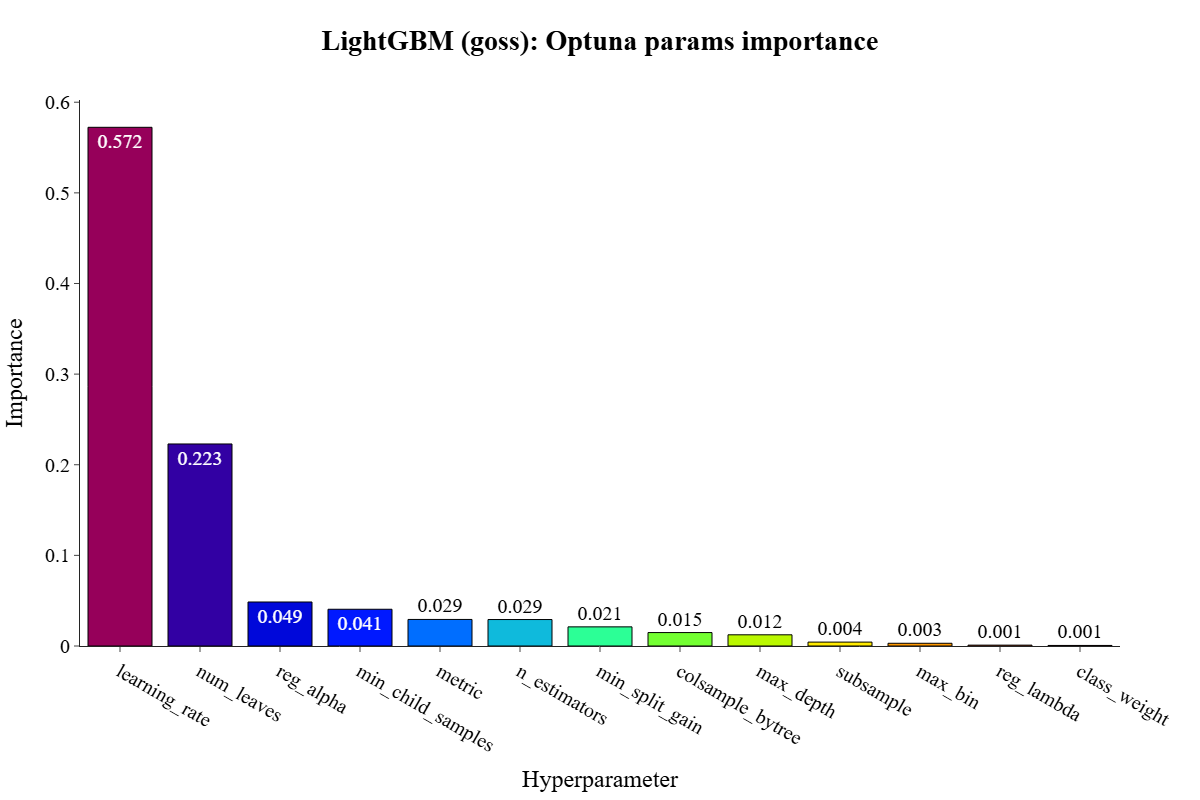

In [53]:
optuna_plots.plot_optuna_param_importance(study, plot_title="LightGBM (goss): Optuna params importance")

In [54]:
model = LGBMClassifier(**lgbm_goss_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9694 +- 0.0005
Validation Accuracy: 0.9693 +- 0.0020


## XGBoost

In [55]:
model = XGBClassifier()
constant_params_grid = {
    "seed": ("constant", [SEED]),
    "verbosity": ("constant", [0]),
    "n_jobs": ("constant", [-1]),
    "tree_method": ("constant", ["hist"]),
    "enable_categorical": ("constant", [True]),
    "early_stopping_rounds": ("constant", [100]),
}
constant_params_grid["objective"] = ("constant", ["binary:logistic"])

tunable_params_grid = {
    "n_estimators": ("int", [200, 2000], {"step": 50}),
    "learning_rate": ("float", [1e-4, 0.3], {"log": True}),
    "max_depth": ("int", [0, 30], {"step": 1}),
    "min_child_weight": ("int", [1, 296], {"step": 5}),
    "subsample": ("float", [0.4, 1.0], {"log": False}),
    "colsample_bytree": ("float", [0.4, 1.0], {"log": False}),
    "gamma": ("float", [1e-4, 10.0], {"log": True}),
    "reg_alpha": ("float", [1e-4, 10.0], {"log": True}),
    "reg_lambda": ("float", [1e-4, 10.0], {"log": True}),
    "max_bin": ("int", [63, 511], {"step": 32}),
}
tunable_params_grid["eval_metric"] = ("categorical", ["logloss", "auc"])
tunable_params_grid["scale_pos_weight"] = ("float", [0.5, 10.0], {"log": True})

params_grid = {**constant_params_grid, **tunable_params_grid}


study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
xgb_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
xgb_best_params = {**constant_params, **xgb_best_params}
print(xgb_best_params)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\optuna\_experimental.py:31: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-08-16 13:52:02,493] A new study created in memory with name: Optuna tuning
[I 2025-08-16 13:52:05,927] Trial 0 finished with value: 0.9663680654535491 and parameters: {'n_estimators': 700, 'learning_rate': 0.0069970420741033885, 'max_depth': 5, 'min_child_weight': 21, 'subsample': 0.872191275999948, 'colsample_bytree': 0.7938001130655132, 'gamma': 0.15402970378226535, 'reg_alpha': 0.07551173844071643, 'reg_lambda': 0.00015678863564170368, 'max_bin': 223, 'eval_metric': 'logloss', 'scale_pos_weight': 6.6544888018064725}. Best is trial 0 with value: 0.9663680654535491.
[I 2025-08-16 13:52:14,716] Trial 1 finished with value: 0.7395270969415564 and parameters: {'n_estimators': 1800, 'learning_rate': 0.00015066299028163713, 'max_depth': 20, 'min_child_weight': 166, 'subsample': 0

{'seed': 17, 'verbosity': 0, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': True, 'early_stopping_rounds': 100, 'objective': 'binary:logistic', 'n_estimators': 800, 'learning_rate': 0.20344605972076077, 'max_depth': 23, 'min_child_weight': 116, 'subsample': 0.7257230398646841, 'colsample_bytree': 0.8605302952004623, 'gamma': 0.00020869537774026366, 'reg_alpha': 0.5652824019514912, 'reg_lambda': 0.44373363438832947, 'max_bin': 479, 'eval_metric': 'logloss', 'scale_pos_weight': 0.7891958688979775}


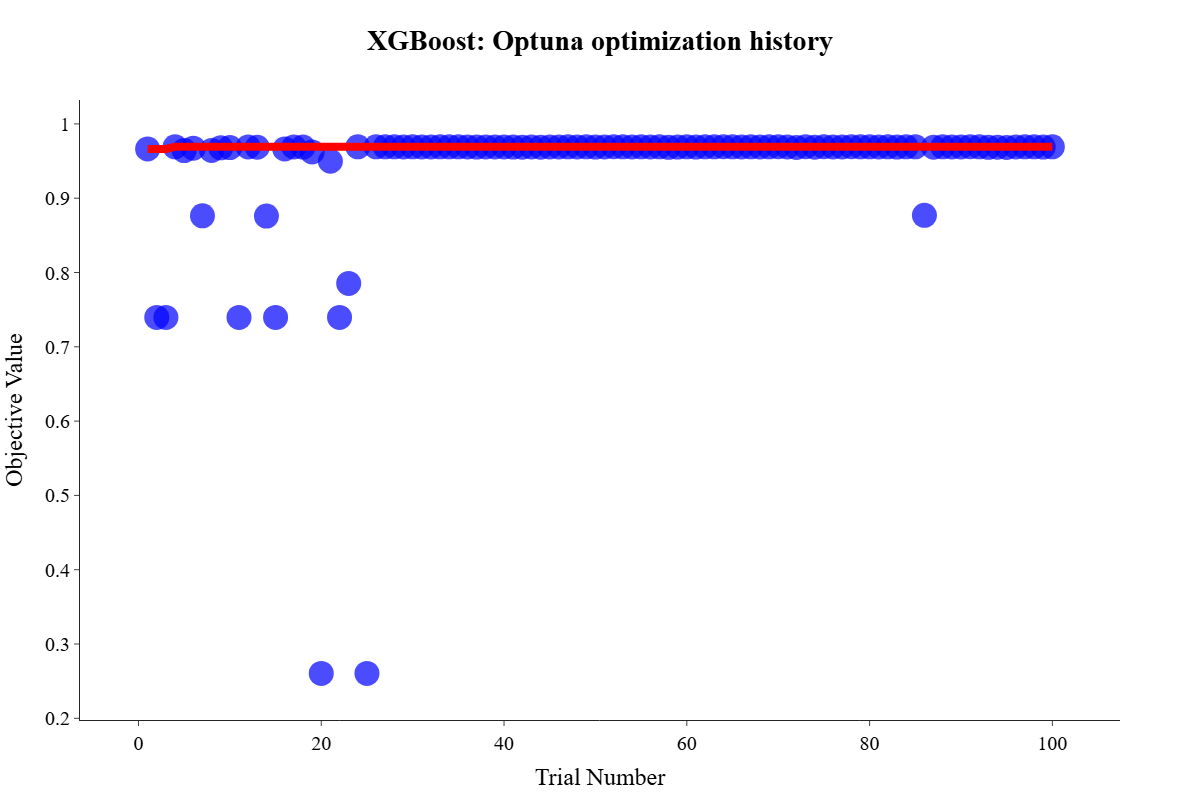

In [56]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="XGBoost: Optuna optimization history", direction=METRICS[METRIC_NAME][2])

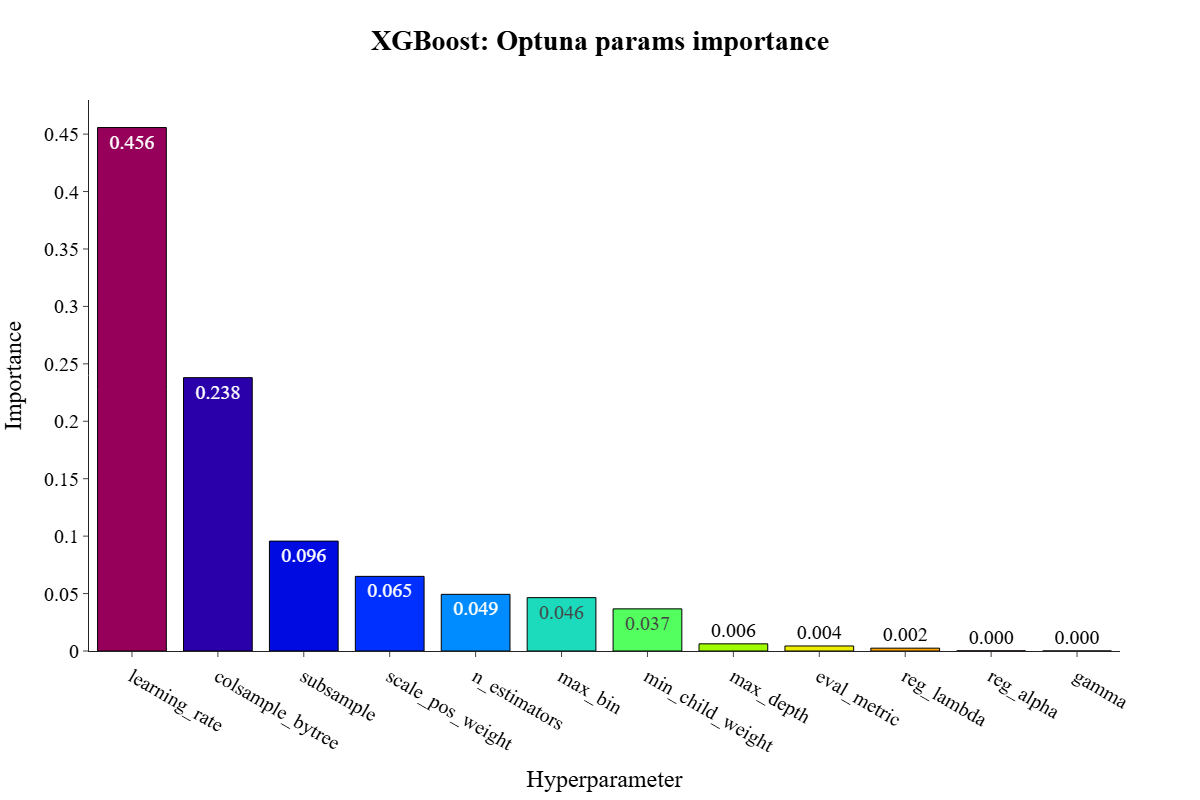

In [57]:
optuna_plots.plot_optuna_param_importance(study, plot_title="XGBoost: Optuna params importance")

In [58]:
model = XGBClassifier(**xgb_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9694 +- 0.0006
Validation Accuracy: 0.9694 +- 0.0020


## Histogram-based Gradient Boosting

In [59]:
model = HistGradientBoostingClassifier()
constant_params_grid = {
    "random_state": ("constant", [SEED]),
    "verbose": ("constant", [0]),
    "categorical_features": ("constant", [categorical_features]),
    "early_stopping": ("constant", [True]),
}
constant_params_grid["loss"] = ("constant", ["log_loss"])

tunable_params_grid = {
    "learning_rate": ("float", [1e-4, 0.3], {"log": True}),
    "max_iter": ("int", [200, 2000], {"step": 50}),
    "max_leaf_nodes": ("int", [15, 510], {"step": 5}),
    "max_depth": ("int", [3, 30], {"step": 1}),
    "max_features": ("float", [0.4, 1.0], {"log": False}),
    "min_samples_leaf": ("int", [5, 300], {"step": 5}),
    "l2_regularization": ("float", [1e-4, 30.0], {"log": True}),
    "max_bins": ("int", [64, 224], {"step": 32}),
    "n_iter_no_change": ("int", [10, 50], {"step": 5}),
    "validation_fraction": ("float", [0.1, 0.3], {"log": False}),
}
tunable_params_grid["scoring"] = ("categorical", ["neg_log_loss", "roc_auc"])
tunable_params_grid["class_weight"] = ("categorical", ["balanced", None])

params_grid = {**constant_params_grid, **tunable_params_grid}

study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
hgbm_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
hgbm_best_params = {**constant_params, **hgbm_best_params}
print(hgbm_best_params)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\optuna\_experimental.py:31: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-08-16 13:54:57,309] A new study created in memory with name: Optuna tuning
[I 2025-08-16 13:55:28,425] Trial 0 finished with value: 0.9692291515464188 and parameters: {'learning_rate': 0.0010582443144853525, 'max_iter': 1150, 'max_leaf_nodes': 110, 'max_depth': 4, 'max_features': 0.872191275999948, 'min_samples_leaf': 200, 'l2_regularization': 0.310298195529844, 'max_bins': 160, 'n_iter_no_change': 10, 'validation_fraction': 0.1715627208967098, 'scoring': 'neg_log_loss', 'class_weight': None}. Best is trial 0 with value: 0.9692291515464188.
[I 2025-08-16 13:56:45,042] Trial 1 finished with value: 0.967717622266332 and parameters: {'learning_rate': 0.00015066299028163713, 'max_iter': 1400, 'max_leaf_nodes': 290, 'max_depth': 19, 'max_features': 0.6901171745860013, 'min_samples

{'random_state': 17, 'verbose': 0, 'categorical_features': ['large_friend_circle', 'time_alone_low', 'Stage_fear', 'frequent_poster', 'Drained_after_socializing'], 'early_stopping': True, 'loss': 'log_loss', 'learning_rate': 0.027802671489991843, 'max_iter': 1050, 'max_leaf_nodes': 275, 'max_depth': 16, 'max_features': 0.6002108476861477, 'min_samples_leaf': 70, 'l2_regularization': 5.383943366547139, 'max_bins': 96, 'n_iter_no_change': 50, 'validation_fraction': 0.18799752475332346, 'scoring': 'roc_auc', 'class_weight': None}


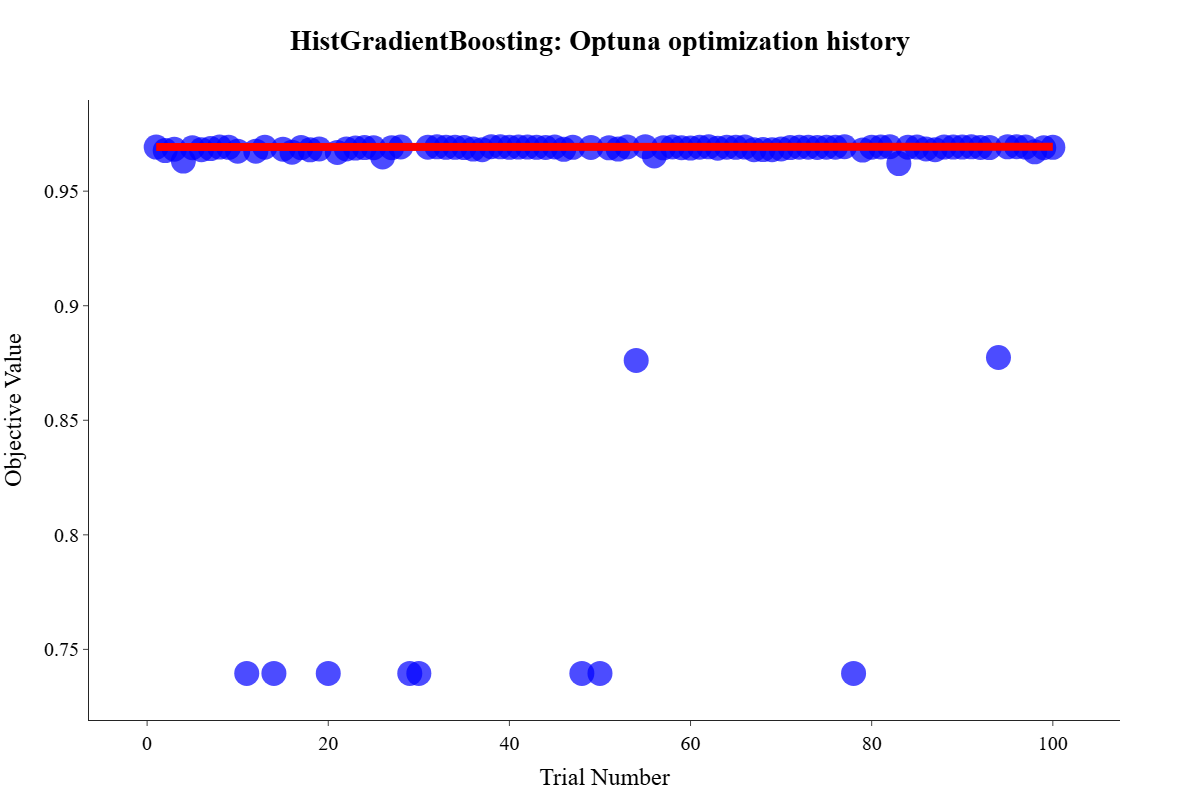

In [60]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="HistGradientBoosting: Optuna optimization history", direction=METRICS[METRIC_NAME][2])

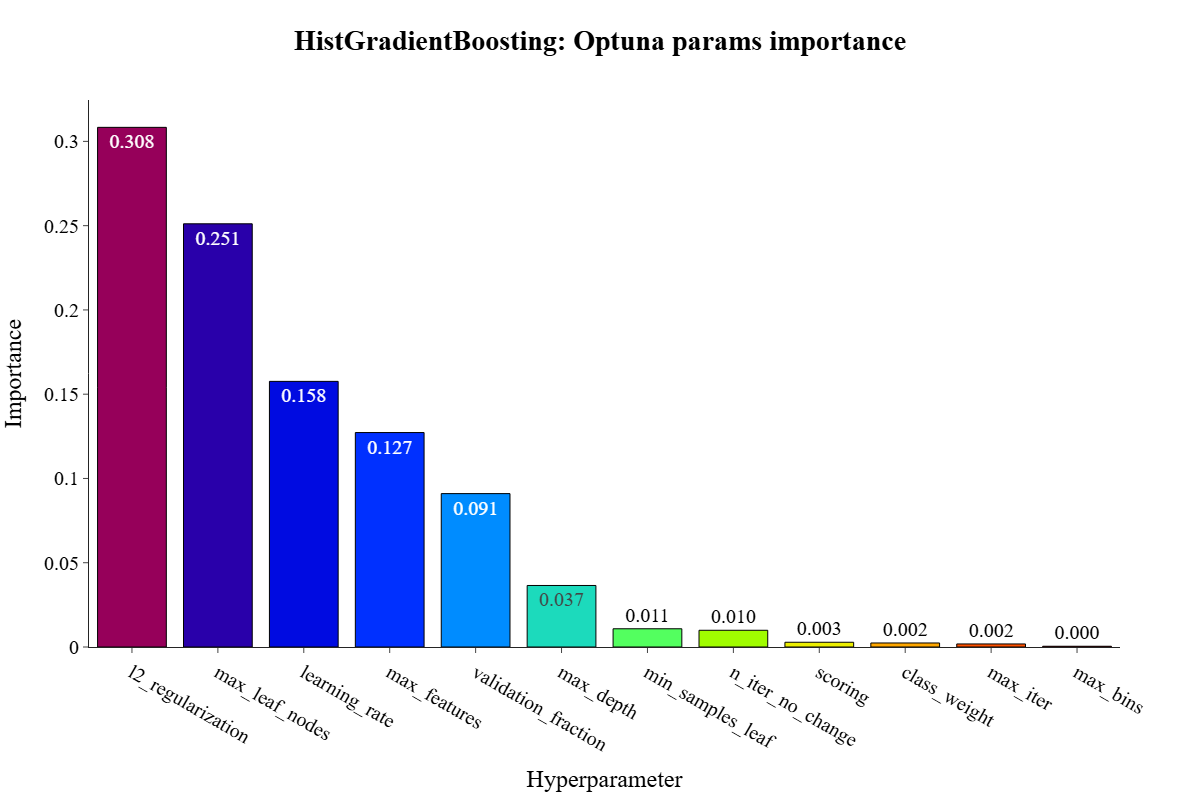

In [61]:
optuna_plots.plot_optuna_param_importance(study, plot_title="HistGradientBoosting: Optuna params importance")

In [62]:
model = HistGradientBoostingClassifier(**hgbm_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9698 +- 0.0007
Validation Accuracy: 0.9694 +- 0.0019


## Catboost

In [63]:
model = CatBoostClassifier()
constant_params_grid = {
    "random_state": ("constant", [SEED]),
    "verbose": ("constant", [0]),
    "cat_features": ("constant", [categorical_features]),
    "task_type": ("constant", ["GPU"]),
    "allow_writing_files": ("constant", [False]),
    "thread_count": ("constant", [-1]),
    "early_stopping_rounds": ("constant", [100]),
}
constant_params_grid["loss_function"] = ("constant", ["Logloss"])
constant_params_grid["eval_metric"] = ("constant", ["Logloss"])

tunable_params_grid = {
    "iterations": ("int", [50, 2000], {"step": 50}),
    "learning_rate": ("float", [1e-3, 0.3], {"log": True}),
    "depth": ("int", [3, 10], {"step": 1}),
    "l2_leaf_reg": ("float", [1e-3, 30], {"log": True}),
    "random_strength": ("float", [1e-3, 10.0], {"log": True}),
    "bagging_temperature": ("float", [0.3, 1.0], {"log": True}),
    "min_data_in_leaf": ("int", [1, 296], {"step": 5}),
    "max_bin": ("int", [32, 480], {"step": 32}),
}
tunable_params_grid["auto_class_weights"] = ("categorical", ["Balanced", "SqrtBalanced", "None"])

params_grid = {**constant_params_grid, **tunable_params_grid}

study = tuner.tune(model, train_data[independent_features], train_data[target_feature], params_grid)
catboost_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
catboost_best_params = {**constant_params, **catboost_best_params}
print(catboost_best_params)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\optuna\_experimental.py:31: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-08-16 14:13:03,173] A new study created in memory with name: Optuna tuning
[I 2025-08-16 14:13:52,744] Trial 0 finished with value: 0.9691212039069264 and parameters: {'iterations': 600, 'learning_rate': 0.0206218550445619, 'depth': 4, 'l2_leaf_reg': 0.00201371561093265, 'random_strength': 1.4058592411732862, 'bagging_temperature': 0.6611562428979949, 'min_data_in_leaf': 191, 'max_bin': 288, 'auto_class_weights': 'None'}. Best is trial 0 with value: 0.9691212039069264.
[I 2025-08-16 14:14:20,267] Trial 1 finished with value: 0.9683114581602703 and parameters: {'iterations': 150, 'learning_rate': 0.138145600849423, 'depth': 10, 'l2_leaf_reg': 0.0016951192212950569, 'random_strength': 0.407075028414586, 'bagging_temperature': 0.5829352503057804, 'min_data_in_leaf': 176, 'max_bi

{'random_state': 17, 'verbose': 0, 'cat_features': ['large_friend_circle', 'time_alone_low', 'Stage_fear', 'frequent_poster', 'Drained_after_socializing'], 'task_type': 'GPU', 'allow_writing_files': False, 'thread_count': -1, 'early_stopping_rounds': 100, 'loss_function': 'Logloss', 'eval_metric': 'Logloss', 'iterations': 1350, 'learning_rate': 0.0014262713792928192, 'depth': 3, 'l2_leaf_reg': 0.37790222895051645, 'random_strength': 0.02149087173755945, 'bagging_temperature': 0.3358918128706524, 'min_data_in_leaf': 206, 'max_bin': 128, 'auto_class_weights': 'None'}


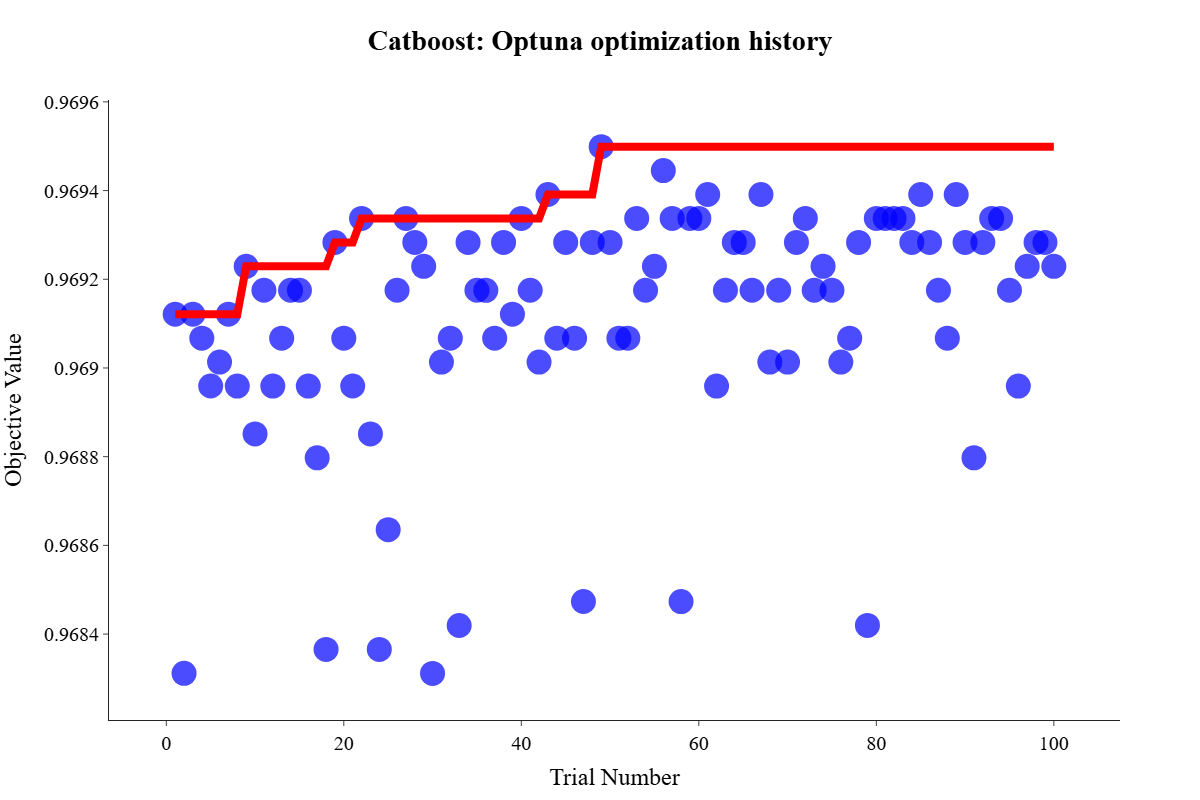

In [64]:
optuna_plots.plot_optuna_optimization_history(study, plot_title="Catboost: Optuna optimization history", direction=METRICS[METRIC_NAME][2])

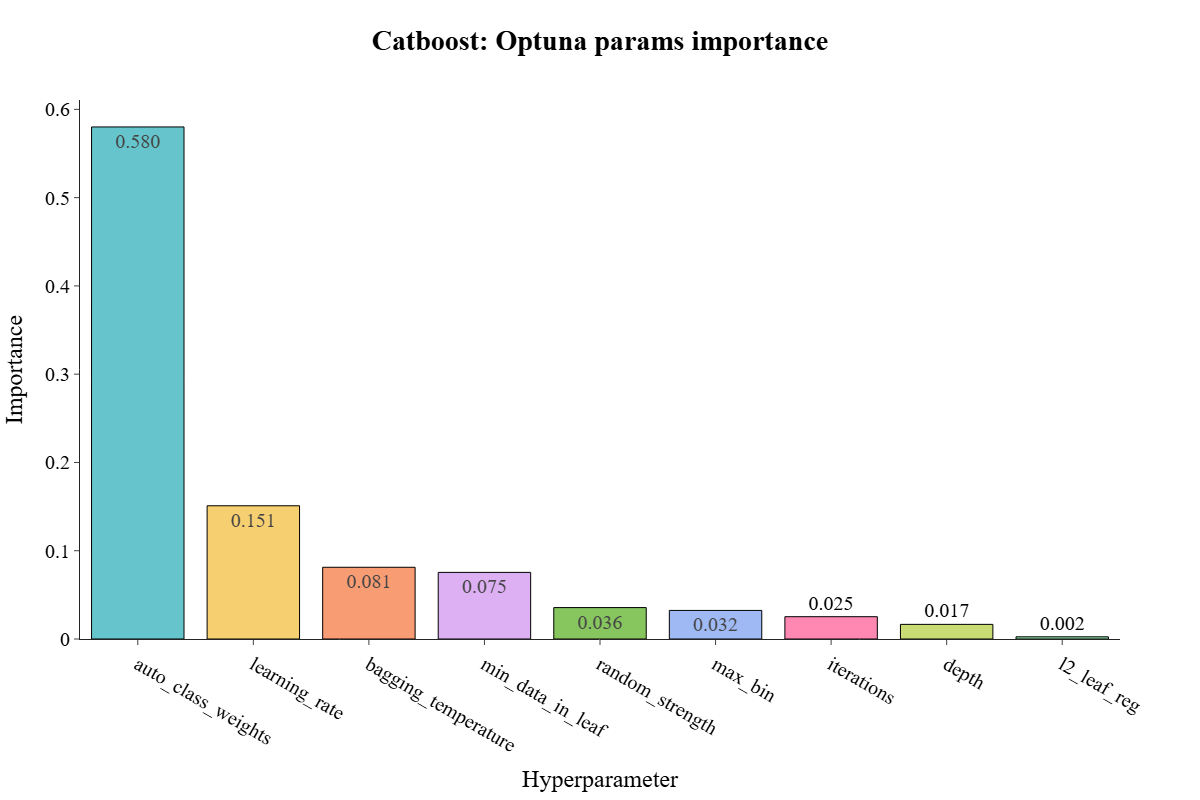

In [65]:
optuna_plots.plot_optuna_param_importance(study, plot_title="Catboost: Optuna params importance")

In [66]:
model = CatBoostClassifier(**catboost_best_params)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9697 +- 0.0005
Validation Accuracy: 0.9695 +- 0.0018


## Ensemble weights tuning

In [67]:
# estimators = [
#     LGBMClassifier(**lgbm_best_params),
#     LGBMClassifier(**lgbm_goss_best_params),
#     XGBClassifier(**xgb_best_params),
#     HistGradientBoostingClassifier(**hgbm_best_params),
#     CatBoostClassifier(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='Logloss', eval_metric='Logloss', early_stopping_rounds=100, allow_writing_files=False)
# ]

estimators = [
    LGBMClassifier(**lgbm_best_params),
    LGBMClassifier(**lgbm_goss_best_params),
    XGBClassifier(**xgb_best_params),
    HistGradientBoostingClassifier(**hgbm_best_params),
    CatBoostClassifier(**catboost_best_params)
]

ensemble_weights_tuner = EnsembleWeightTunerCV(
    estimators = estimators,
    cross_validator = cross_validation_trainer,
    n_trials = N_TRIALS*5,
    seed = SEED,
    allow_negative_weights = True,
)
ensemble_weights_tuner.tune(train_data[independent_features], train_data[target_feature])
best_weights = ensemble_weights_tuner.best_weights
for i, estimator in enumerate(ensemble_weights_tuner.estimators):
    print(f"Estimator {i}: {estimator.__class__.__name__}, Weight: {best_weights[i]:.4f}")

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\optuna\_experimental.py:31: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-08-16 17:43:35,867] A new study created in memory with name: Ensemble weight tuning
[I 2025-08-16 17:43:35,867] Trial 0 finished with value: 0.7395270999784064 and parameters: {'w0': -0.4106699946257806, 'w1': 0.06117351121058823, 'w2': -0.6169584261050103, 'w3': -0.8641992836174173, 'w4': 0.5739709199998266}. Best is trial 0 with value: 0.7395270999784064.
[I 2025-08-16 17:43:35,867] Trial 1 finished with value: 0.7395270999784064 and parameters: {'w0': 0.31266704355171093, 'w1': 0.27504179208727164, 'w2': 0.15120578750606795, 'w3': -0.921874167622267, 'w4': -0.28437279103290214}. Best is trial 0 with value: 0.7395270999784064.
[I 2025-08-16 17:43:35,876] Trial 2 finished with value: 0.7395270999784064 and parameters: {'w0': 0.8913663736368151, 'w1': -0.8799106393692293, 'w2

Estimator 0: LGBMClassifier, Weight: 0.1839
Estimator 1: LGBMClassifier, Weight: 0.0823
Estimator 2: XGBClassifier, Weight: 0.4853
Estimator 3: HistGradientBoostingClassifier, Weight: 0.2099
Estimator 4: CatBoostClassifier, Weight: -0.0385


In [68]:
ensemble_model = EnsembleModel(estimators=ensemble_weights_tuner.estimators, problem_type=PROBLEM_TYPE, weights=ensemble_weights_tuner.best_weights)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[target_feature])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train Accuracy: 0.9696 +- 0.0006
Validation Accuracy: 0.9693 +- 0.0019


In [69]:
final_model = ensemble_model

## Cutoff tuning

In [70]:
cutoff_tuner = CutoffTunerCV(
    estimator=final_model,
    metric_name=METRIC_NAME if METRICS[METRIC_NAME][1] != "probs" else "F1",
    cross_validator=cross_validation_trainer,
    n_trials=N_TRIALS*5,
    seed=SEED,
)
cutoff_tuner.tune(train_data[independent_features], train_data[target_feature])
cutoffs = cutoff_tuner.best_cutoffs
print("Optimal cutoffs:")
for i, cutoff in enumerate(cutoffs):
    print(f"   - {id2label[i]}: {cutoff:.4f}")

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\optuna\_experimental.py:31: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

[I 2025-08-16 17:48:57,509] A new study created in memory with name: Cutoff tuning
[I 2025-08-16 17:48:57,511] Trial 0 finished with value: 0.9687972360181386 and parameters: {'cutoff': 0.2987717026333675}. Best is trial 0 with value: 0.9687972360181386.
[I 2025-08-16 17:48:57,512] Trial 1 finished with value: 0.969445044266897 and parameters: {'cutoff': 0.5299750204931882}. Best is trial 1 with value: 0.969445044266897.
[I 2025-08-16 17:48:57,514] Trial 2 finished with value: 0.9680414597279206 and parameters: {'cutoff': 0.19769037120854496}. Best is trial 1 with value: 0.969445044266897.
[I 2025-08-16 17:48:57,516] Trial 3 finished with value: 0.9620492334269056 and parameters: {'cutoff': 0.07654235102746554}. Best is trial 1 with value: 0.969445044266897.
[I 2025-08-16 17:48:57,51

Optimal cutoffs:
   - Extrovert: 0.5424


# Evaluation

In [71]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.2, random_state=SEED, shuffle=True, stratify=train_data[target_feature])

In [72]:
final_model.fit(train_data_temp[independent_features], train_data_temp[target_feature], eval_set=[(test_data_temp[independent_features], test_data_temp[target_feature])])

y_train = train_data_temp[target_feature]
y_train_pred = final_model.predict(train_data_temp[independent_features])
y_train_prob = final_model.predict_proba(train_data_temp[independent_features])
y_train_labels = y_train.map(id2label)
y_train_pred_labels = pd.Series(y_train_pred).map(id2label)

y_test = test_data_temp[target_feature]
y_test_pred = final_model.predict(test_data_temp[independent_features])
y_test_prob = final_model.predict_proba(test_data_temp[independent_features])
y_test_labels = y_test.map(id2label)
y_test_pred_labels = pd.Series(y_test_pred).map(id2label)

In [73]:
def postprocess_predictions(predictions: np.ndarray, cutoffs: list[float]) -> np.ndarray:
    """
    Postprocess predictions using the optimal cutoffs.
    
    Args:
        predictions (np.ndarray): Predictions from the model.
        cutoffs (list[float]): Optimal cutoffs for each class. If binary classification, then there is only one element and the first element is the cutoff for the positive class.
    
    Returns:
        np.ndarray: Postprocessed predictions.
    """
    if predictions.ndim == 1:
        return (predictions >= cutoffs[0]).astype(int)
    elif predictions.ndim == 2:
        return np.argmax(predictions >= cutoffs, axis=1)
    else:
        raise ValueError("Predictions must be 1D or 2D array.")

y_train_pred_postprocessed = postprocess_predictions(y_train_prob, cutoffs)
y_test_pred_postprocessed = postprocess_predictions(y_test_prob, cutoffs)
y_train_pred_labels_postprocessed = pd.Series(y_train_pred_postprocessed).map(id2label)
y_test_pred_labels_postprocessed = pd.Series(y_test_pred_postprocessed).map(id2label)

In [74]:
print("Without postprocessing:")
display(classification_results(y_train_true=y_train_labels, y_train_pred=y_train_pred_labels, y_test_true=y_test_labels, y_test_pred=y_test_pred_labels, y_train_proba=y_train_prob, y_test_proba=y_test_prob))
print("With postprocessing:")
classification_results(y_train_true=y_train_labels, y_train_pred=y_train_pred_labels_postprocessed, y_test_true=y_test_labels, y_test_pred=y_test_pred_labels_postprocessed, y_train_proba=y_train_prob, y_test_proba=y_test_prob)

Without postprocessing:


,Accuracy,Precision,Recall,F1-Score (weighted),F1-Score (macro),ROC-AUC
Train,0.9698,0.9697,0.9698,0.9697,0.9606,0.9866
Test,0.9684,0.9683,0.9684,0.9684,0.9589,0.9681


With postprocessing:


,Accuracy,Precision,Recall,F1-Score (weighted),F1-Score (macro),ROC-AUC
Train,0.9698,0.9697,0.9698,0.9697,0.9606,0.9866
Test,0.9687,0.9686,0.9687,0.9686,0.9592,0.9681


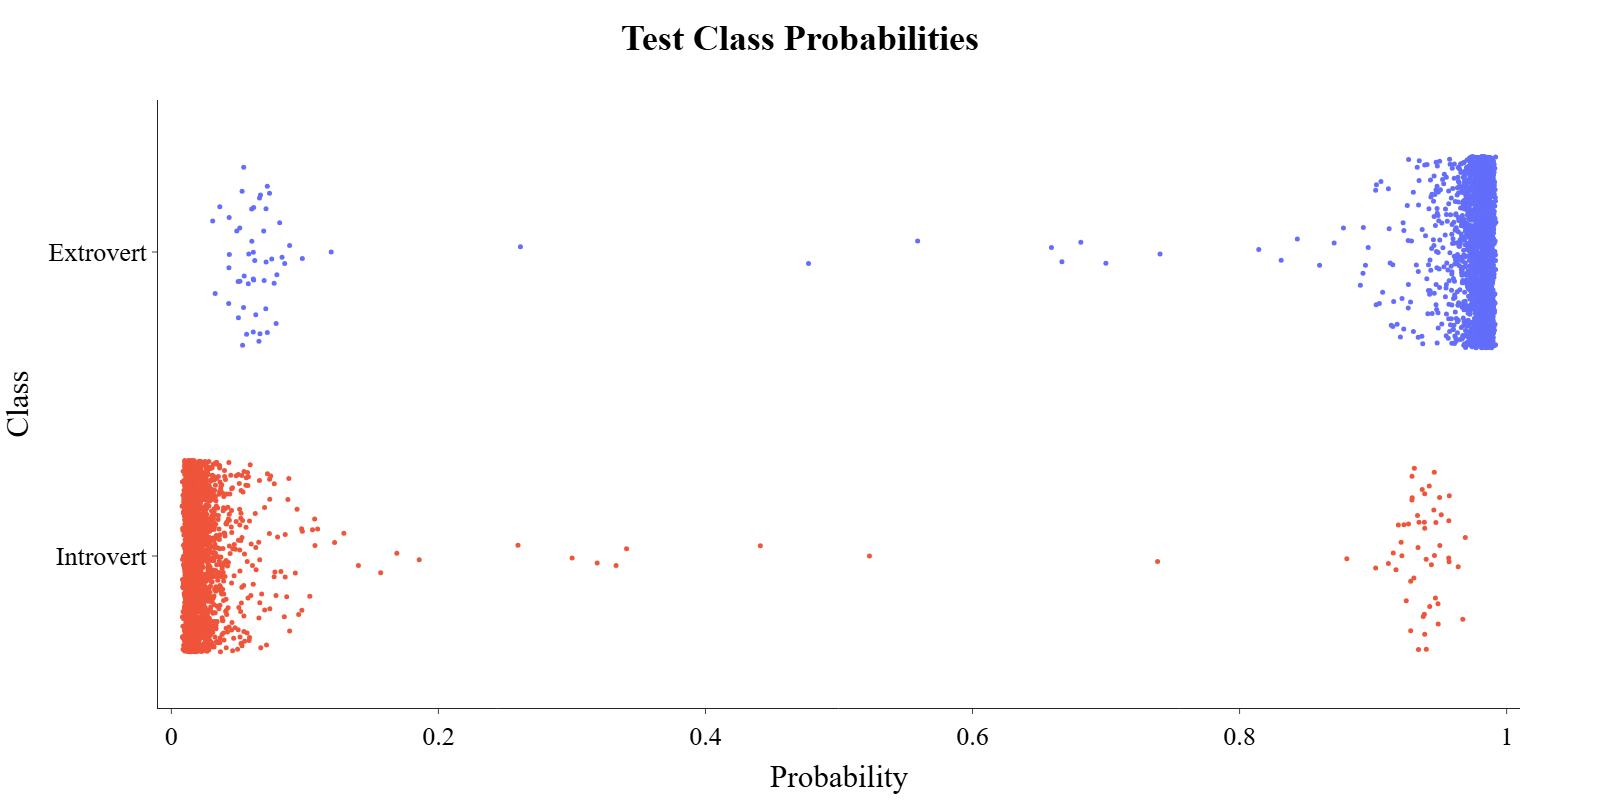

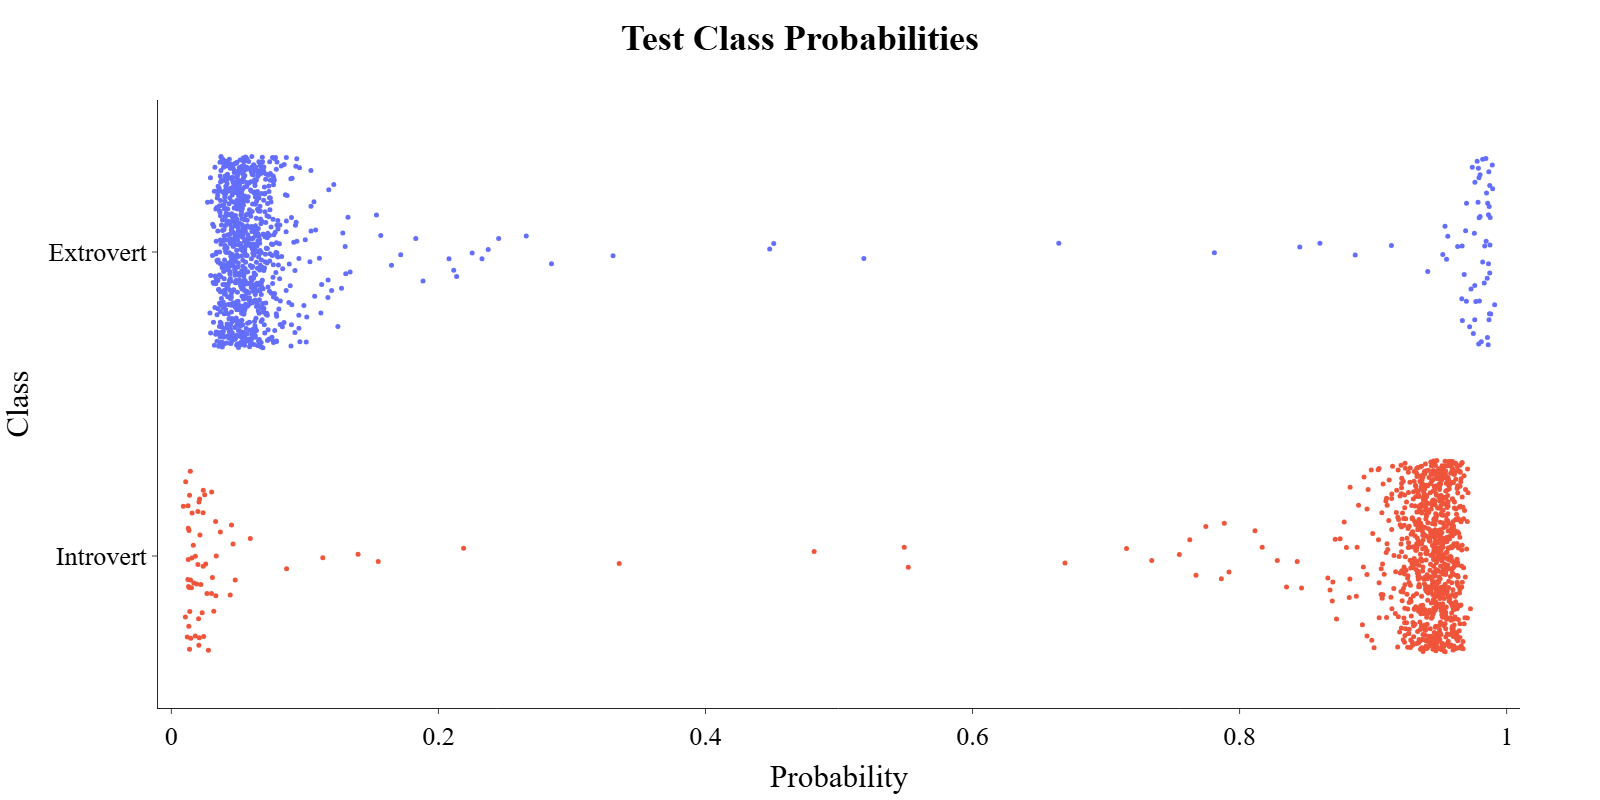

In [75]:
classification_plots.plot_probabilities_per_class(y_true=y_test_labels, probabilities=y_test_prob, id2label=id2label, plot_title="Test Class Probabilities")

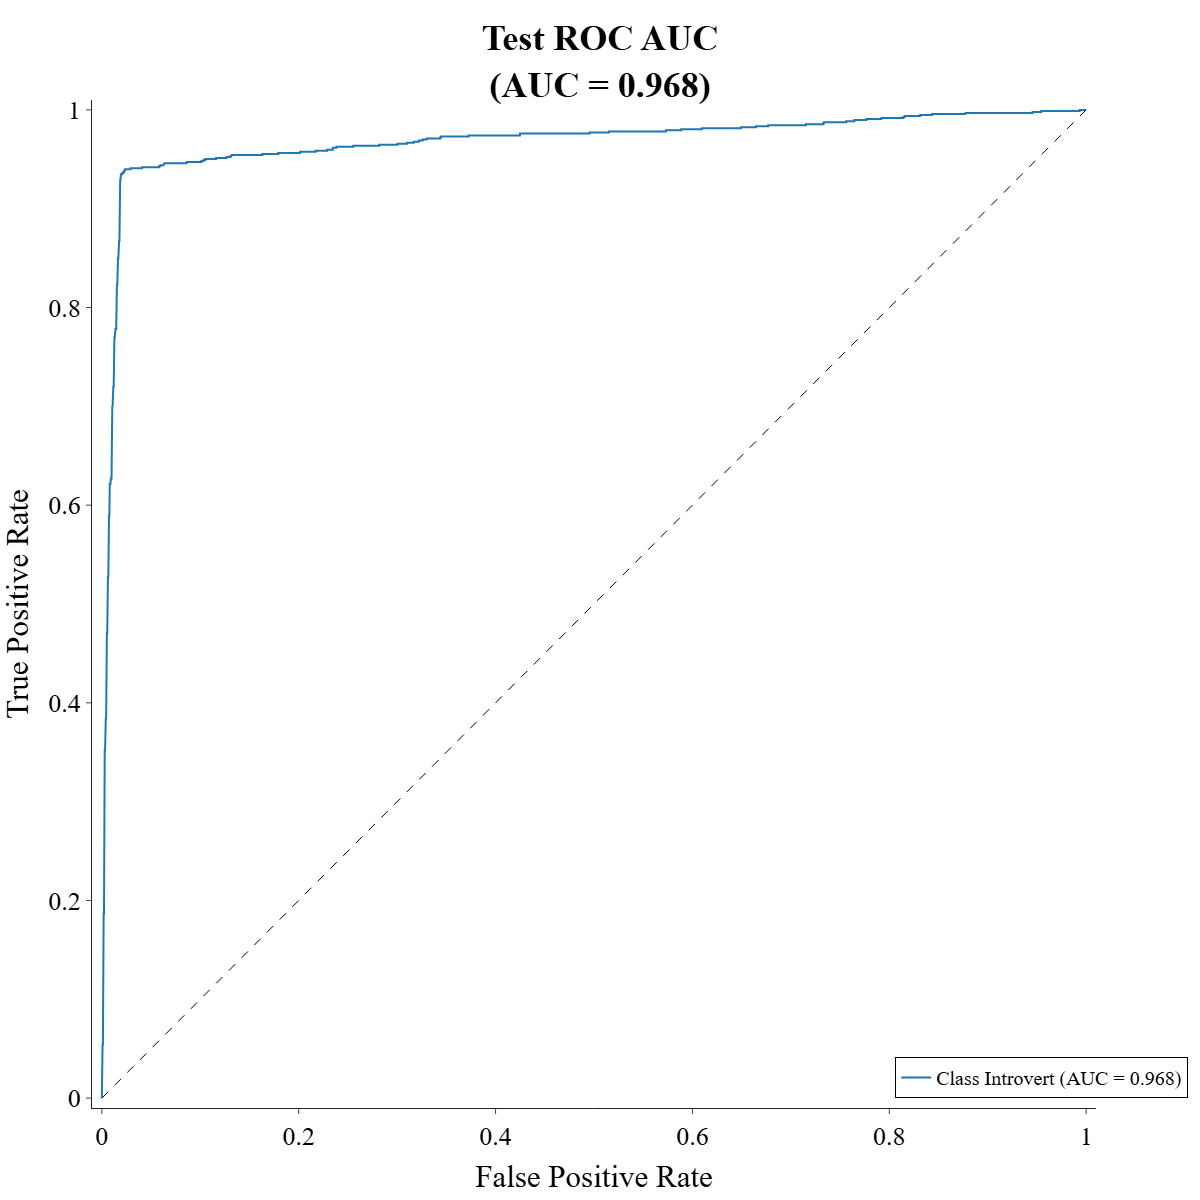

In [76]:
classification_plots.plot_roc_auc(y_true=y_test, probabilities=y_test_prob, id2label=id2label, plot_title="Test ROC AUC")

## Submission (traditional approach)

In [77]:
final_model_no_early_stopping = deepcopy(final_model)
for idx, estimator in enumerate(final_model_no_early_stopping.estimators):
    if hasattr(estimator, 'early_stopping_rounds'):
        final_model_no_early_stopping.estimators[idx].set_params(early_stopping_rounds=None)
final_model_no_early_stopping.fit(train_data[independent_features], train_data[target_feature])
submission = pd.read_csv("input/sample_submission.csv")
y_test_prob = final_model_no_early_stopping.predict_proba(test_data[independent_features])[:, 1]
submission[target_feature] = pd.Series(postprocess_predictions(y_test_prob, cutoffs)).map(id2label)
submission.to_csv("submission.csv", index=False)
submission.head()

,id,Personality
0,18524,Extrovert
1,18525,Introvert
2,18526,Extrovert
3,18527,Extrovert
4,18528,Introvert


## Submission (validation set approach)

In [78]:
final_model.fit(train_data_temp[independent_features], train_data_temp[target_feature], eval_set=[(test_data_temp[independent_features], test_data_temp[target_feature])])
submission = pd.read_csv("input/sample_submission.csv")
y_test_prob = final_model_no_early_stopping.predict_proba(test_data[independent_features])[:, 1]
submission[target_feature] = pd.Series(postprocess_predictions(y_test_prob, cutoffs)).map(id2label)
submission.to_csv("submission.csv", index=False)
submission.head()

,id,Personality
0,18524,Extrovert
1,18525,Introvert
2,18526,Extrovert
3,18527,Extrovert
4,18528,Introvert


## Submission (OOF approach)

In [79]:
train_scores, valid_scores, avg_test_pred = cross_validation_trainer.fit(estimator=final_model, X=train_data[independent_features], y=train_data[target_feature], X_test=test_data[independent_features])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")
submission = pd.read_csv("input/sample_submission.csv")
submission[target_feature] = pd.Series(postprocess_predictions(avg_test_pred, cutoffs)).map(id2label)
submission.to_csv("submission.csv", index=False)
submission.head()

Train Accuracy: 0.9696 +- 0.0006
Validation Accuracy: 0.9693 +- 0.0019


,id,Personality
0,18524,Extrovert
1,18525,Introvert
2,18526,Extrovert
3,18527,Extrovert
4,18528,Introvert
